# **Property Price and Market Trend Analysis.**

## Importing required libraries and loading the dataset.

In [1]:
# Importing all the Packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r'Property_finder_dataset.csv')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Analysing the Loaded dataset.

In [3]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
df.shape
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [7]:
df.isna().sum().sort_values(ascending=False).head(19)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


## Data preprocessing

In [8]:
numerical_features=df.select_dtypes(include=['int64', 'float64']).columns.tolist() # Creating a new feature with by segregating all the numerical features
categorical_features=df.select_dtypes(include=['object']).columns.tolist() # Creating a new feature with by segregating all the categorical features

print("Numerical Features:", len(numerical_features))
print("Categorical Features:", len(categorical_features))


Numerical Features: 38
Categorical Features: 43


In [9]:
df[numerical_features]=df[numerical_features].fillna(df[numerical_features].median()) # Handling the missing data my filling the NULL value with median for Numerical column
df[categorical_features]=df[categorical_features].fillna(df[categorical_features].mode().iloc[0]) # Handling the missing data my filling the NULL value with mode for Categorical column

In [10]:
print("Missing values after cleaning:")
df.isnull().sum().sum() # Checking the Null Values after cleaning

Missing values after cleaning:


np.int64(0)

In [11]:
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist() # Checking the Unique vale in each categorical feature
for i in cat_cols:
 print(f'{i}:{df[i].unique()}')

MSZoning:['RL' 'RM' 'C (all)' 'FV' 'RH']
Street:['Pave' 'Grvl']
Alley:['Grvl' 'Pave']
LotShape:['Reg' 'IR1' 'IR2' 'IR3']
LandContour:['Lvl' 'Bnk' 'Low' 'HLS']
Utilities:['AllPub' 'NoSeWa']
LotConfig:['Inside' 'FR2' 'Corner' 'CulDSac' 'FR3']
LandSlope:['Gtl' 'Mod' 'Sev']
Neighborhood:['CollgCr' 'Veenker' 'Crawfor' 'NoRidge' 'Mitchel' 'Somerst' 'NWAmes'
 'OldTown' 'BrkSide' 'Sawyer' 'NridgHt' 'NAmes' 'SawyerW' 'IDOTRR'
 'MeadowV' 'Edwards' 'Timber' 'Gilbert' 'StoneBr' 'ClearCr' 'NPkVill'
 'Blmngtn' 'BrDale' 'SWISU' 'Blueste']
Condition1:['Norm' 'Feedr' 'PosN' 'Artery' 'RRAe' 'RRNn' 'RRAn' 'PosA' 'RRNe']
Condition2:['Norm' 'Artery' 'RRNn' 'Feedr' 'PosN' 'PosA' 'RRAn' 'RRAe']
BldgType:['1Fam' '2fmCon' 'Duplex' 'TwnhsE' 'Twnhs']
HouseStyle:['2Story' '1Story' '1.5Fin' '1.5Unf' 'SFoyer' 'SLvl' '2.5Unf' '2.5Fin']
RoofStyle:['Gable' 'Hip' 'Gambrel' 'Mansard' 'Flat' 'Shed']
RoofMatl:['CompShg' 'WdShngl' 'Metal' 'WdShake' 'Membran' 'Tar&Grv' 'Roll'
 'ClyTile']
Exterior1st:['VinylSd' 'MetalSd' 'Wd

In [12]:
df_title=['LandContour','Utilities','LotConfig','Neighborhood','Condition1','Condition2','BldgType',
            'RoofMatl','Exterior1st','Exterior2nd','MasVnrType','Foundation','BsmtFinType1','BsmtFinType2','Heating',
            'Electrical','GarageType','GarageFinish','Fence','MiscFeature','SaleType']
for i in df_title:
    df[i] = df[i].astype(str).str.strip().str.title() # Making the Header of the categorical feature same

In [13]:
for i in cat_cols:
  print(f'{i}:{df[i].unique()}')

MSZoning:['RL' 'RM' 'C (all)' 'FV' 'RH']
Street:['Pave' 'Grvl']
Alley:['Grvl' 'Pave']
LotShape:['Reg' 'IR1' 'IR2' 'IR3']
LandContour:['Lvl' 'Bnk' 'Low' 'Hls']
Utilities:['Allpub' 'Nosewa']
LotConfig:['Inside' 'Fr2' 'Corner' 'Culdsac' 'Fr3']
LandSlope:['Gtl' 'Mod' 'Sev']
Neighborhood:['Collgcr' 'Veenker' 'Crawfor' 'Noridge' 'Mitchel' 'Somerst' 'Nwames'
 'Oldtown' 'Brkside' 'Sawyer' 'Nridght' 'Names' 'Sawyerw' 'Idotrr'
 'Meadowv' 'Edwards' 'Timber' 'Gilbert' 'Stonebr' 'Clearcr' 'Npkvill'
 'Blmngtn' 'Brdale' 'Swisu' 'Blueste']
Condition1:['Norm' 'Feedr' 'Posn' 'Artery' 'Rrae' 'Rrnn' 'Rran' 'Posa' 'Rrne']
Condition2:['Norm' 'Artery' 'Rrnn' 'Feedr' 'Posn' 'Posa' 'Rran' 'Rrae']
BldgType:['1Fam' '2Fmcon' 'Duplex' 'Twnhse' 'Twnhs']
HouseStyle:['2Story' '1Story' '1.5Fin' '1.5Unf' 'SFoyer' 'SLvl' '2.5Unf' '2.5Fin']
RoofStyle:['Gable' 'Hip' 'Gambrel' 'Mansard' 'Flat' 'Shed']
RoofMatl:['Compshg' 'Wdshngl' 'Metal' 'Wdshake' 'Membran' 'Tar&Grv' 'Roll'
 'Clytile']
Exterior1st:['Vinylsd' 'Metalsd' 'Wd

## New Features required for analysis:

In [14]:
df['HouseAge']     = df['YrSold'] - df['YearBuilt']                       # creating a new feature to find the age of the property
df['WasRemodeled'] = (df['YearBuilt'] != df['YearRemodAdd']).astype(int)  # creating a new feature to find out whether the property was renovated or not
df['RemodelAge']   = df['YrSold'] - df['YearRemodAdd']                    # creating a new feature to find how recently the property was renovated
df['TotalSF']      = df['GrLivArea'] + df['TotalBsmtSF']                  # creating a new feature to find the total Sq Ft of the property
df['PricePerSqFt'] = df['SalePrice'] / df['GrLivArea']                    # creating a new feature to find the Price per sqt ft of the property

def get_season(m):                                                        # Labeling the numerical data to categorical data  to know exactly what type of season are we dealing with for further analysis
    return {1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',
            6:'Summer',7:'Summer',8:'Summer',9:'Fall',10:'Fall',11:'Fall',12:'Winter'}[m]
df['Season'] = df['MoSold'].map(get_season)

qual_decode = {'Ex':'Excellent','Gd':'Good','TA':'Average','Fa':'Fair','Po':'Poor'} # Labelling Quality in much ore readable manner
for col in ['ExterQual','KitchenQual','BsmtQual','FireplaceQu','GarageQual','HeatingQC']:
    if col in df.columns:
        df[col] = df[col].map(qual_decode).fillna('None')

nb_median = df.groupby('Neighborhood')['SalePrice'].median()
df['NB_Tier'] = df['Neighborhood'].map(
    lambda x: 'Premium (>$200k)' if nb_median[x] > 200_000
    else ('Mid-Range ($130k–$200k)' if nb_median[x] > 130_000 else 'Affordable (<$130k)')) # Labelling Property Tier in much more understanable manner
df['Has_Garage'] = df['GarageCars'] > 0
df['Has_DeckPorch'] = (df['WoodDeckSF'] > 0) | (df['OpenPorchSF'] > 0) | (df['EnclosedPorch'] > 0)
df['Has_Pool'] = df['PoolArea'] > 0

garage, no_garage = df['Has_Garage'].sum(), (~df['Has_Garage']).sum()
deck, no_deck = df['Has_DeckPorch'].sum(), (~df['Has_DeckPorch']).sum()
pool, no_pool = df['Has_Pool'].sum(), (~df['Has_Pool']).sum()

medians_with = {
    'Garage': df[df['Has_Garage']]['SalePrice'].median() / 1000,
    'Deck/Porch': df[df['Has_DeckPorch']]['SalePrice'].median() / 1000,
    'Pool': df[df['Has_Pool']]['SalePrice'].median() / 1000
}
medians_without = {
    'Garage': df[~df['Has_Garage']]['SalePrice'].median() / 1000,
    'Deck/Porch': df[~df['Has_DeckPorch']]['SalePrice'].median() / 1000,
    'Pool': df[~df['Has_Pool']]['SalePrice'].median() / 1000
}
labels = ['Garage', 'Deck/Porch', 'Pool']
premiums = [
    ((medians_with['Garage'] / medians_without['Garage']) - 1) * 100,
    ((medians_with['Deck/Porch'] / medians_without['Deck/Porch']) - 1) * 100,
    ((medians_with['Pool'] / medians_without['Pool']) - 1) * 100
]
print(f"Dataset: {df.shape[0]:,} properties  |  {df.shape[1]} features after engineering")
print(f"Price range : ${df.SalePrice.min():,.0f}  ->  ${df.SalePrice.max():,.0f}")
print(f"Median price: ${df.SalePrice.median():,.0f}   |   Mean: ${df.SalePrice.mean():,.0f}")

Dataset: 1,460 properties  |  91 features after engineering
Price range : $34,900  ->  $755,000
Median price: $163,000   |   Mean: $180,921


In [15]:
df.to_csv('cleaned_dataset.csv', index=False)

# **Aditya Mathew**

## Section 1: Where does my property sit in the market?

In [16]:
df['SalePrice'].describe()

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


In [17]:
df['SalePrice'].quantile([0.25,0.50,0.75])

,SalePrice
0.25,129975.0
0.50,163000.0
0.75,214000.0


<Axes: xlabel='SalePrice', ylabel='Count'>

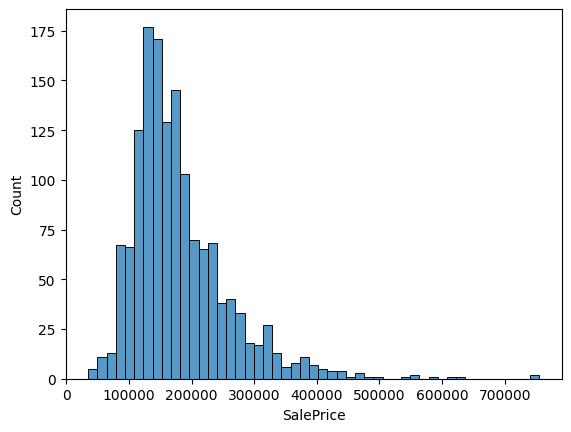

In [18]:
sns.histplot(data=df['SalePrice'])

In [19]:
GOLD    = '#C9A84C'
DARK    = '#1C2833'
BLUE    = '#2471A3'
GREEN   = '#1E8449'
RED     = '#C0392B'
ORANGE  = '#E67E22'
PURPLE  = '#7D3C98'
LIGHT   = '#F2F3F4'
PALETTE = [BLUE, GOLD, GREEN, RED, ORANGE, PURPLE, '#17A589', '#943126']

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.titlesize': 12,
    'figure.facecolor': 'white',
})
fmt_k = lambda x, _: f'${x:.0f}k'

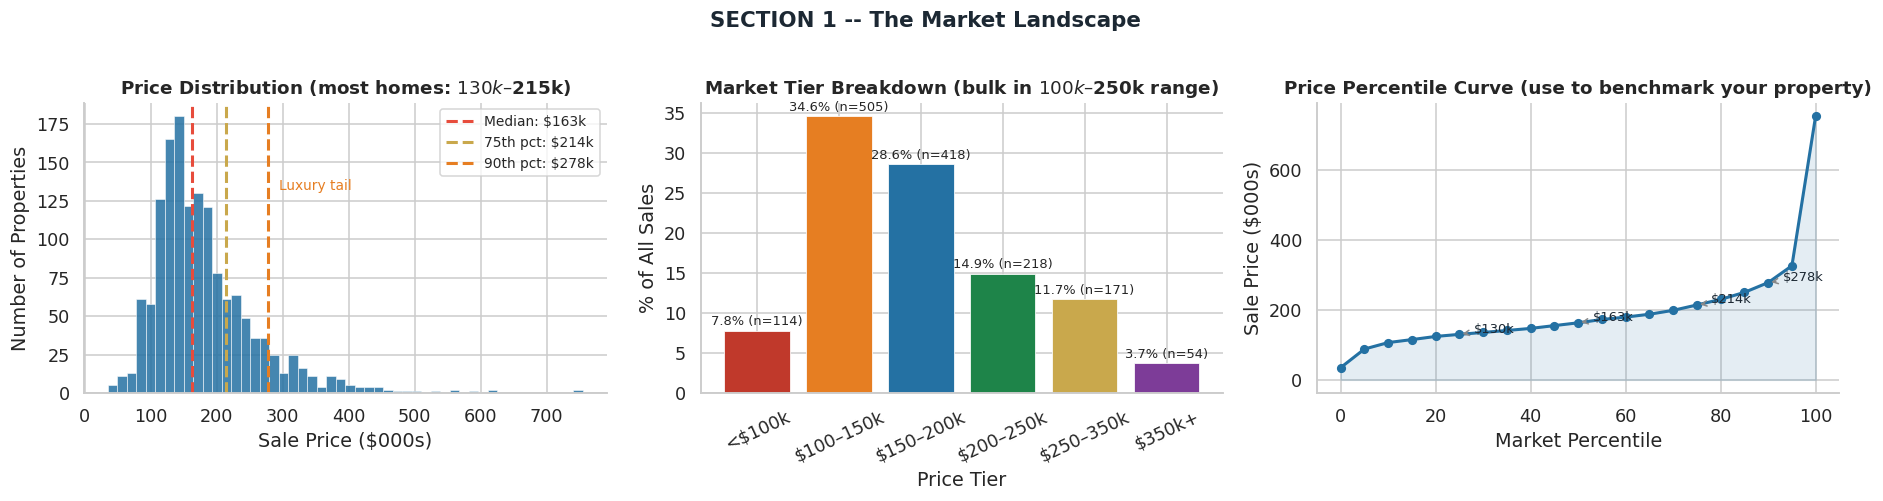

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# (a) Price distribution with market tiers

price_data = df['SalePrice'] / 1000
q25, q50, q75, q90 = price_data.quantile([.25,.50,.75,.90])
axes[0].hist(price_data, bins=50, color=BLUE, edgecolor='white', linewidth=0.4, alpha=0.85)
for val, label, color in [(q50,'Median','#E74C3C'), (q75,'75th pct',GOLD), (q90,'90th pct',ORANGE)]:
    axes[0].axvline(val, color=color, lw=2, ls='--', label=f'{label}: ${val:.0f}k')
axes[0].set_xlabel('Sale Price ($000s)')
axes[0].set_ylabel('Number of Properties')
axes[0].set_title('Price Distribution (most homes: $130k–$215k)')
axes[0].legend(fontsize=9)
axes[0].text(350, axes[0].get_ylim()[1]*0.7, 'Luxury tail', fontsize=9, color=ORANGE, ha='center')

# (b) Price tier breakdown

tiers   = ['<$100k','$100–150k','$150–200k','$200–250k','$250–350k','$350k+']
counts  = [
    (df.SalePrice < 100_000).sum(),
    df.SalePrice.between(100_000,150_000).sum(),
    df.SalePrice.between(150_000,200_000).sum(),
    df.SalePrice.between(200_000,250_000).sum(),
    df.SalePrice.between(250_000,350_000).sum(),
    (df.SalePrice > 350_000).sum()
]
pcts = [c / len(df) * 100 for c in counts]
tier_colors = [RED, ORANGE, BLUE, GREEN, GOLD, PURPLE]
bars = axes[1].bar(tiers, pcts, color=tier_colors, edgecolor='white', linewidth=0.5)
for bar, pct, cnt in zip(bars, pcts, counts):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{pct:.1f}% (n={cnt})', ha='center', va='bottom', fontsize=8.5)
axes[1].set_xlabel('Price Tier')
axes[1].set_ylabel('% of All Sales')
axes[1].set_title('Market Tier Breakdown (bulk in $100k–$250k range)')
axes[1].tick_params(axis='x', rotation=25)

# (c) Percentile curve

pcts_range = np.arange(0, 101, 5)
price_pcts = np.percentile(df['SalePrice'], pcts_range) / 1000
axes[2].plot(pcts_range, price_pcts, 'o-', color=BLUE, ms=5, lw=2)
axes[2].fill_between(pcts_range, price_pcts, alpha=0.12, color=BLUE)
# Annotate key points
for p, v in zip([25,50,75,90], np.percentile(df['SalePrice'],[25,50,75,90])/1000):
    axes[2].annotate(f'${v:.0f}k', xy=(p, v), xytext=(p+3, v+5),
                     fontsize=8.5, color=DARK,
                     arrowprops=dict(arrowstyle='->', color='#888', lw=1))
axes[2].set_xlabel('Market Percentile')
axes[2].set_ylabel('Sale Price ($000s)')
axes[2].set_title('Price Percentile Curve (use to benchmark your property)')

plt.suptitle('SECTION 1 -- The Market Landscape', fontsize=14, y=1.01, color=DARK, fontweight='bold')
plt.tight_layout()
plt.show()

## Key Insight
<ol>
<li>(>$350k) is only 8% of the market but represents very different buyer expectations.</li>
<li>If your property is worth 163k, you are right at the market median (50th percentile).</li>
<li>To reach the 75th percentile you need 214k (+31%), and the 90th pct is 278k (+70%).</li>
</ol>

# Section 2: How much does investing in quality pay off?

<Axes: xlabel='OverallQual', ylabel='SalePrice'>

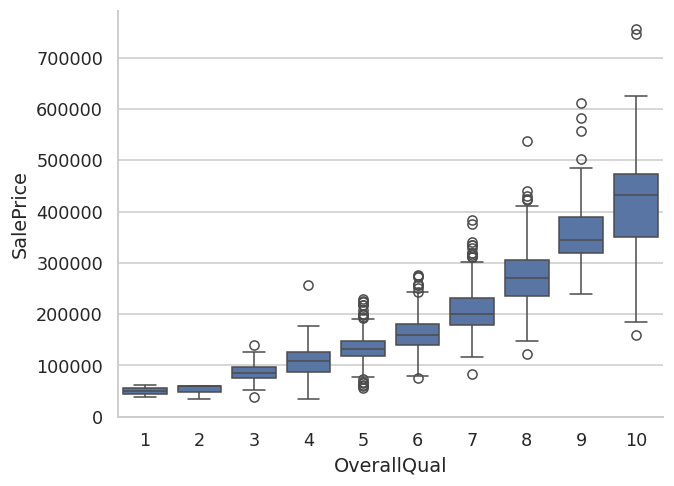

In [21]:
sns.boxplot(data=df,x='OverallQual',y='SalePrice')

In [22]:
df.groupby('OverallQual')['SalePrice'].median()

,SalePrice
OverallQual,
1,50150.0
2,60000.0
3,86250.0
4,108000.0
5,133000.0
6,160000.0
7,200141.0
8,269750.0
9,345000.0


In [23]:
df['Neighborhood'].unique()

array(['Collgcr', 'Veenker', 'Crawfor', 'Noridge', 'Mitchel', 'Somerst',
       'Nwames', 'Oldtown', 'Brkside', 'Sawyer', 'Nridght', 'Names',
       'Sawyerw', 'Idotrr', 'Meadowv', 'Edwards', 'Timber', 'Gilbert',
       'Stonebr', 'Clearcr', 'Npkvill', 'Blmngtn', 'Brdale', 'Swisu',
       'Blueste'], dtype=object)

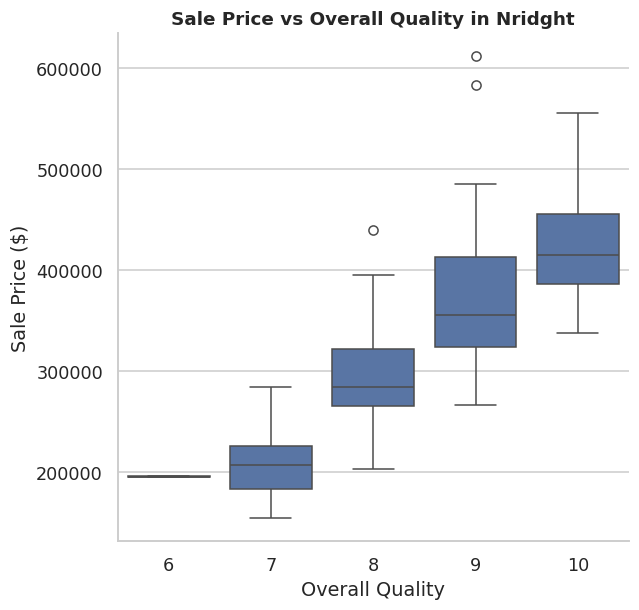

In [24]:
neighborhood = 'Nridght'

plt.figure(figsize=(6,6))

sns.boxplot(
    x='OverallQual',
    y='SalePrice',
    data=df[df['Neighborhood'] == neighborhood]
)

plt.title(f'Sale Price vs Overall Quality in {neighborhood}')
plt.xlabel('Overall Quality')
plt.ylabel('Sale Price ($)')

plt.show()

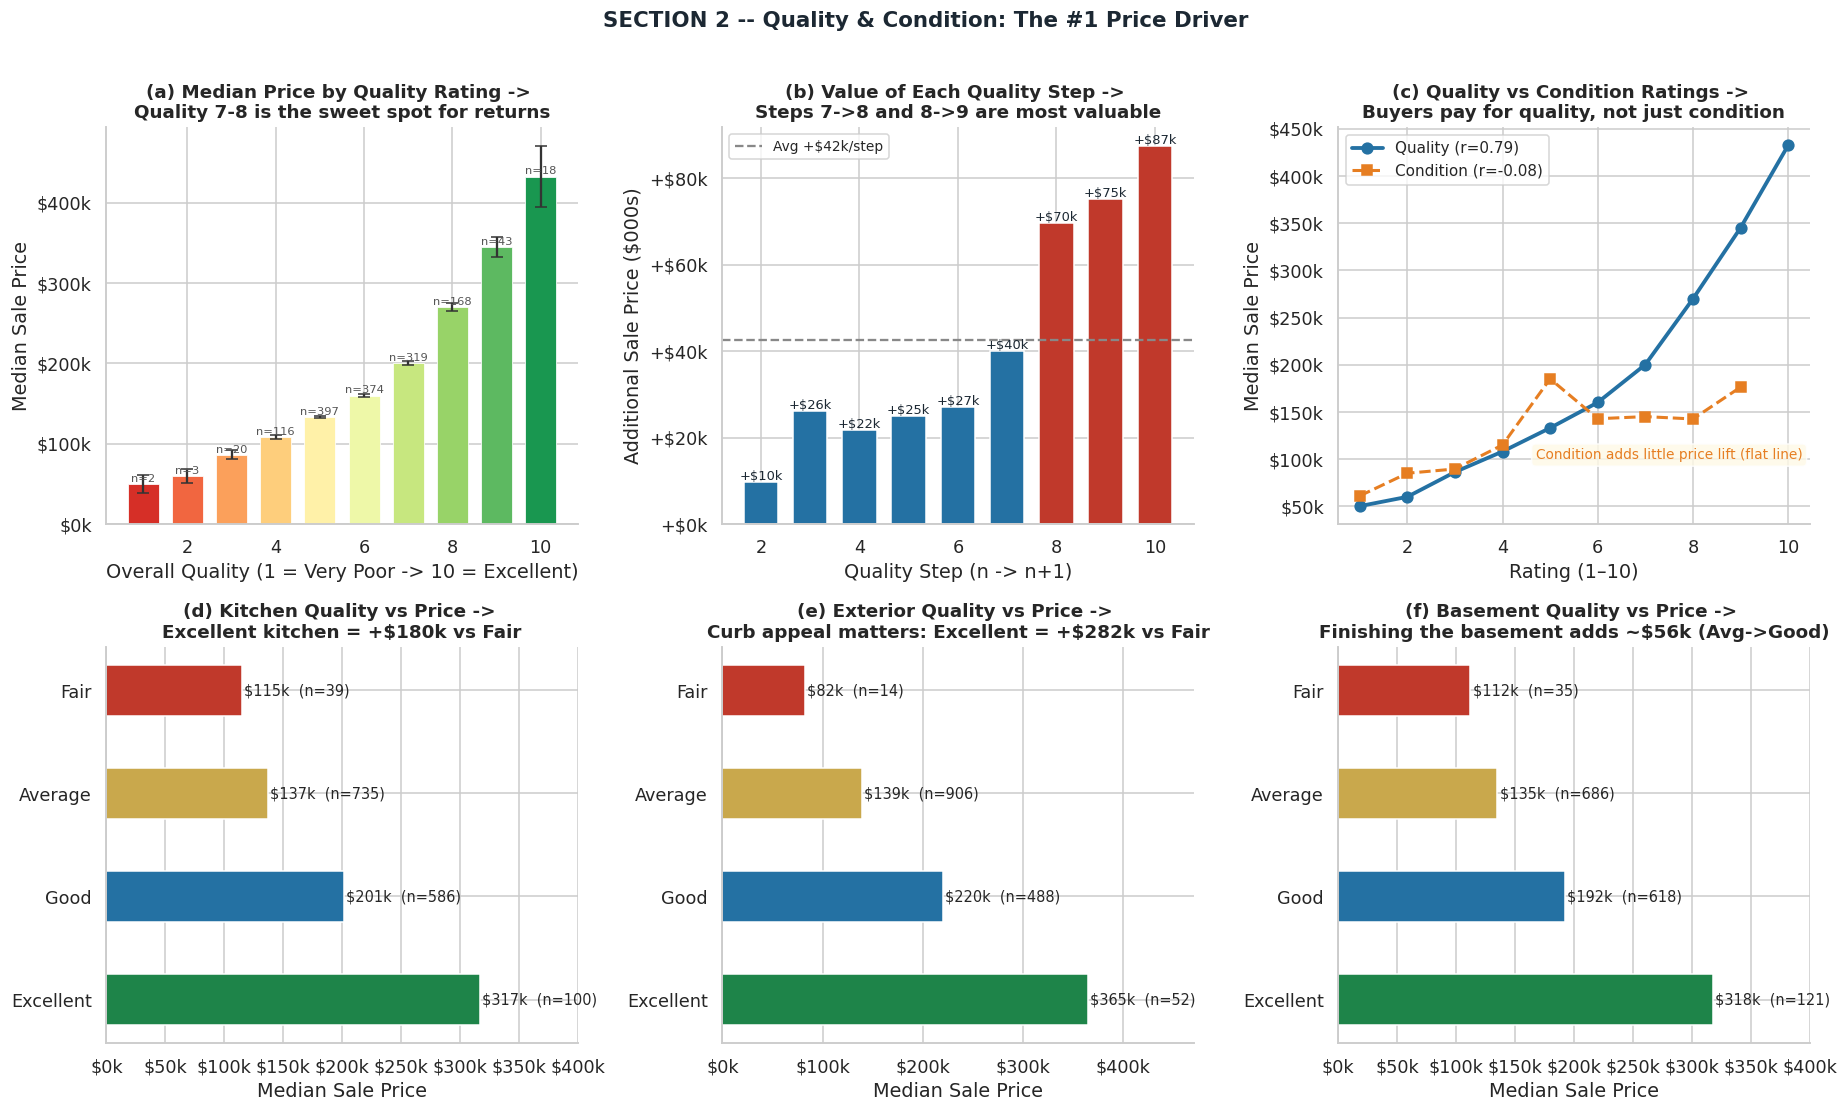

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# (a) Median price ladder by OverallQual
qual_stats = df.groupby('OverallQual')['SalePrice'].agg(['median','count','std']).reset_index()
qual_colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, 10))
bars = axes[0,0].bar(qual_stats['OverallQual'], qual_stats['median']/1000,
                      color=qual_colors, edgecolor='white', linewidth=0.5, width=0.7)
axes[0,0].errorbar(qual_stats['OverallQual'], qual_stats['median']/1000,
                    yerr=qual_stats['std']/1000/np.sqrt(qual_stats['count']),
                    fmt='none', color='#333', capsize=4, lw=1.5)
for bar, row in zip(bars, qual_stats.itertuples()):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                   f'n={row.count}', ha='center', fontsize=7.5, color='#555')
axes[0,0].yaxis.set_major_formatter(mtick.FuncFormatter(fmt_k))
axes[0,0].set_xlabel('Overall Quality (1 = Very Poor -> 10 = Excellent)')
axes[0,0].set_ylabel('Median Sale Price')
axes[0,0].set_title('(a) Median Price by Quality Rating -> \nQuality 7-8 is the sweet spot for returns')

# (b) Price increment per quality step
steps = qual_stats.set_index('OverallQual')['median'].diff().dropna() / 1000
step_colors = [RED if v > steps.mean() else BLUE for v in steps.values]
axes[0,1].bar(steps.index, steps.values, color=step_colors, edgecolor='white', width=0.7)
axes[0,1].axhline(steps.mean(), ls='--', color='#888', lw=1.5, label=f'Avg +${steps.mean():.0f}k/step')
axes[0,1].set_xlabel('Quality Step (n -> n+1)')
axes[0,1].set_ylabel('Additional Sale Price ($000s)')
axes[0,1].set_title('(b) Value of Each Quality Step -> \nSteps 7->8 and 8->9 are most valuable')
axes[0,1].legend(fontsize=9)
axes[0,1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'+${x:.0f}k'))
for i, (idx, v) in enumerate(steps.items()):
    axes[0,1].text(idx, v + 0.5, f'+${v:.0f}k', ha='center', fontsize=8.5, color=DARK)

# (c) OverallQual vs OverallCond
cond_stats = df.groupby('OverallCond')['SalePrice'].median() / 1000
qual_stats2 = df.groupby('OverallQual')['SalePrice'].median() / 1000
axes[0,2].plot(qual_stats2.index, qual_stats2.values, 'o-', color=BLUE, lw=2.5, ms=7, label='Quality (r=0.79)')
axes[0,2].plot(cond_stats.index, cond_stats.values, 's--', color=ORANGE, lw=2, ms=7, label='Condition (r=-0.08)')
axes[0,2].yaxis.set_major_formatter(mtick.FuncFormatter(fmt_k))
axes[0,2].set_xlabel('Rating (1–10)')
axes[0,2].set_ylabel('Median Sale Price')
axes[0,2].set_title('(c) Quality vs Condition Ratings -> \nBuyers pay for quality, not just condition')
axes[0,2].legend(fontsize=10)
axes[0,2].text(7.5, 100, 'Condition adds little price lift (flat line)', fontsize=9,
                color=ORANGE, ha='center', bbox=dict(boxstyle='round,pad=0.3', facecolor='#FEF9E7', alpha=0.8))
# (d) Kitchen quality
kq_order = ['Excellent','Good','Average','Fair']
kq = df[df.KitchenQual.isin(kq_order)].groupby('KitchenQual')['SalePrice'].agg(['median','count'])
kq = kq.reindex(kq_order)
bars = axes[1,0].barh(kq.index, kq['median']/1000, color=[GREEN,BLUE,GOLD,RED], height=0.5)
for bar, (idx, row) in zip(bars, kq.iterrows()):
    axes[1,0].text(row['median']/1000 + 2, bar.get_y()+bar.get_height()/2,
                   f"${row['median']/1000:.0f}k  (n={row['count']:.0f})",
                   va='center', fontsize=9.5)
axes[1,0].xaxis.set_major_formatter(mtick.FuncFormatter(fmt_k))
axes[1,0].set_xlabel('Median Sale Price')
axes[1,0].set_title('(d) Kitchen Quality vs Price -> \nExcellent kitchen = +$180k vs Fair')
axes[1,0].set_xlim(0, 400)

# (e) Exterior quality
eq_order = ['Excellent','Good','Average','Fair']
eq = df[df.ExterQual.isin(eq_order)].groupby('ExterQual')['SalePrice'].agg(['median','count'])
eq = eq.reindex(eq_order)
bars = axes[1,1].barh(eq.index, eq['median']/1000, color=[GREEN,BLUE,GOLD,RED], height=0.5)
for bar, (idx, row) in zip(bars, eq.iterrows()):
    axes[1,1].text(row['median']/1000 + 2, bar.get_y()+bar.get_height()/2,
                   f"${row['median']/1000:.0f}k  (n={row['count']:.0f})",
                   va='center', fontsize=9.5)
axes[1,1].xaxis.set_major_formatter(mtick.FuncFormatter(fmt_k))
axes[1,1].set_xlabel('Median Sale Price')
axes[1,1].set_title('(e) Exterior Quality vs Price -> \nCurb appeal matters: Excellent = +$282k vs Fair')
axes[1,1].set_xlim(0, 470)

# (f) Basement quality (often controllable through finishing)
bq_order = ['Excellent','Good','Average','Fair']
bq = df[df.BsmtQual.isin(bq_order)].groupby('BsmtQual')['SalePrice'].agg(['median','count'])
bq = bq.reindex(bq_order)
bars = axes[1,2].barh(bq.index, bq['median']/1000, color=[GREEN,BLUE,GOLD,RED], height=0.5)
for bar, (idx, row) in zip(bars, bq.iterrows()):
    axes[1,2].text(row['median']/1000 + 2, bar.get_y()+bar.get_height()/2,
                   f"${row['median']/1000:.0f}k  (n={row['count']:.0f})",
                   va='center', fontsize=9.5)
axes[1,2].xaxis.set_major_formatter(mtick.FuncFormatter(fmt_k))
axes[1,2].set_xlabel('Median Sale Price')
axes[1,2].set_title('(f) Basement Quality vs Price -> \nFinishing the basement adds ~$56k (Avg->Good)')
axes[1,2].set_xlim(0, 400)

plt.suptitle('SECTION 2 -- Quality & Condition: The #1 Price Driver',
             fontsize=14, y=1.01, color=DARK, fontweight='bold')
plt.tight_layout()
plt.show()

## Key Insights

<ol>
<li>Upgrading Overall Quality from 5->6 adds 27k; from 7->8 adds 70k.</li>
<li>Overall Condition (maintenance) has almost NO effect on price (r=-0.08).</li>
<li>Kitchen upgrades from Average to Excellent = +$180k median difference.</li>
<li>Exterior quality = first impression; Excellent exterior adds 282k vs Fair.</li>
</ol>

# **Yogambika**

**Outdoor & Extras: Do garages, decks, and pools add real value?**

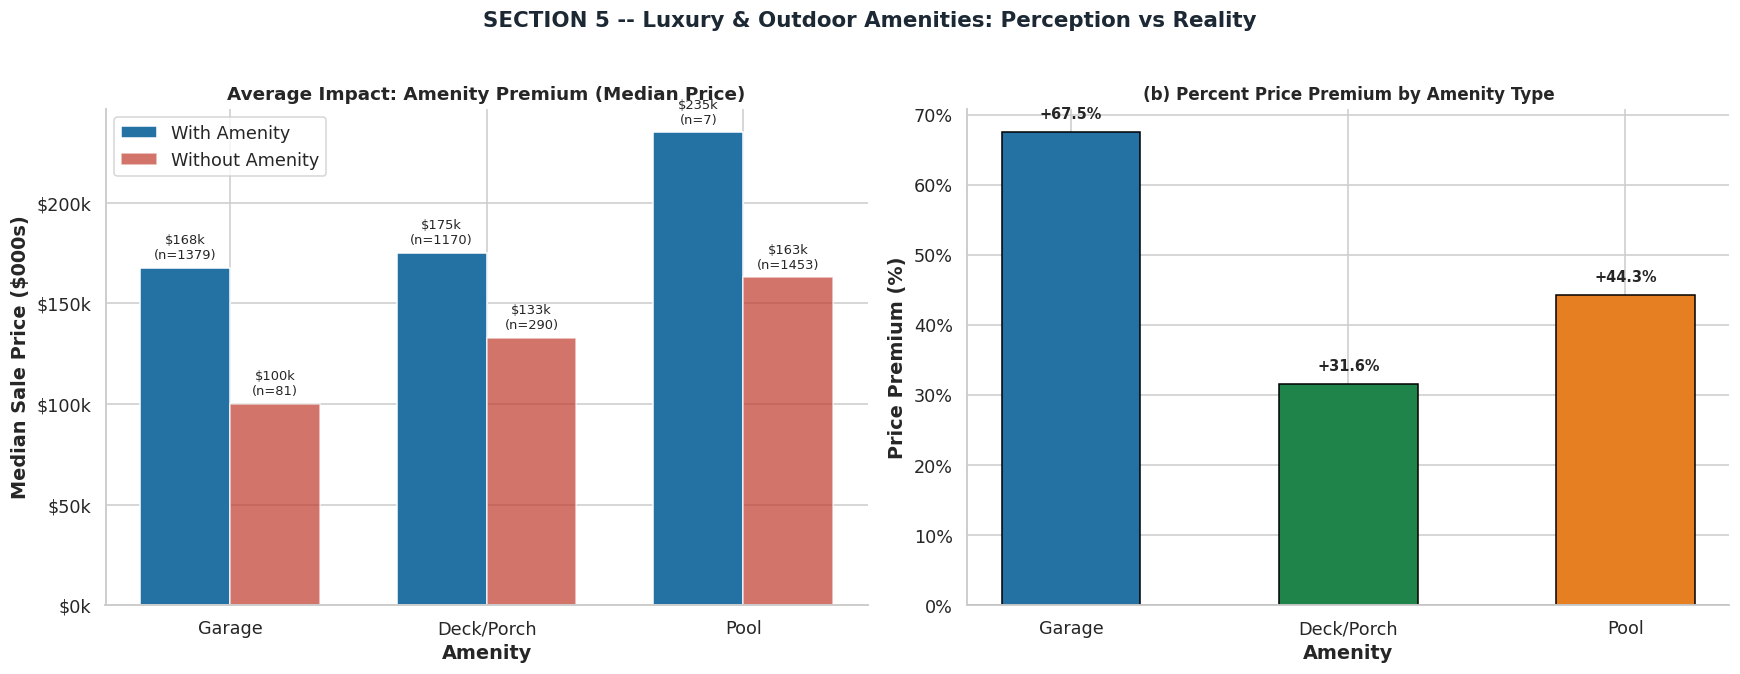

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

labels = ['Garage', 'Deck/Porch', 'Pool']
x = np.arange(len(labels))
width = 0.35
# Comparison: All Amenities Impact on Sales Price
rects1 = axes[0].bar(x - width/2, medians_with.values(), width, label='With Amenity', color=BLUE, edgecolor='white')
rects2 = axes[0].bar(x + width/2, medians_without.values(), width, label='Without Amenity', color=RED, alpha=0.7, edgecolor='white')

axes[0].set_ylabel('Median Sale Price ($000s)', fontweight= 'bold')
axes[0].set_xlabel('Amenity', fontweight= 'bold')
axes[0].set_title('Average Impact: Amenity Premium (Median Price)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].legend()
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(fmt_k))

sample_sizes_with = [garage, deck, pool]
sample_sizes_without = [no_garage, no_deck, no_pool]

for i, bar in enumerate(rects1):
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, yval + 3, f'${yval:.0f}k\n(n={sample_sizes_with[i]})', ha='center', va='bottom', fontsize=8.5)

for i, bar in enumerate(rects2):
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, yval + 3, f'${yval:.0f}k\n(n={sample_sizes_without[i]})', ha='center', va='bottom', fontsize=8.5)

#Percent Price Premium by Amenity Type
colors_premium = [BLUE, GREEN, ORANGE]
premium_bars = axes[1].bar(labels, premiums, color=colors_premium, edgecolor='black', width=0.5)
axes[1].set_ylabel('Price Premium (%)', fontweight='bold')
axes[1].set_xlabel('Amenity', fontweight='bold')
axes[1].set_title('(b) Percent Price Premium by Amenity Type', fontsize=11, fontweight='bold')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

for bar in premium_bars:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, yval + 1.5, f'+{yval:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9.5)

plt.suptitle('SECTION 5 -- Luxury & Outdoor Amenities: Perception vs Reality',
             fontsize=14, y=1.02, color=DARK, fontweight='bold')
plt.tight_layout()
plt.show()

# Key Insights



*   A garage yields a +67.5% price premium (boosting the median from 100k to 168k) and is highly adopted with 1,379 homes.

*   These outdoor spaces add a +31.6% premium (133k to 175k median) and are widely expected by buyers across 1,170 properties.

*   While showing a +44.3% premium ($235k median), pools are only present in 7 homes, meaning luxury estates skew the data.

*   Garages and decks are standard expectations, whereas homes without pools make up the massive market baseline of 1,453 homes ($163k median).





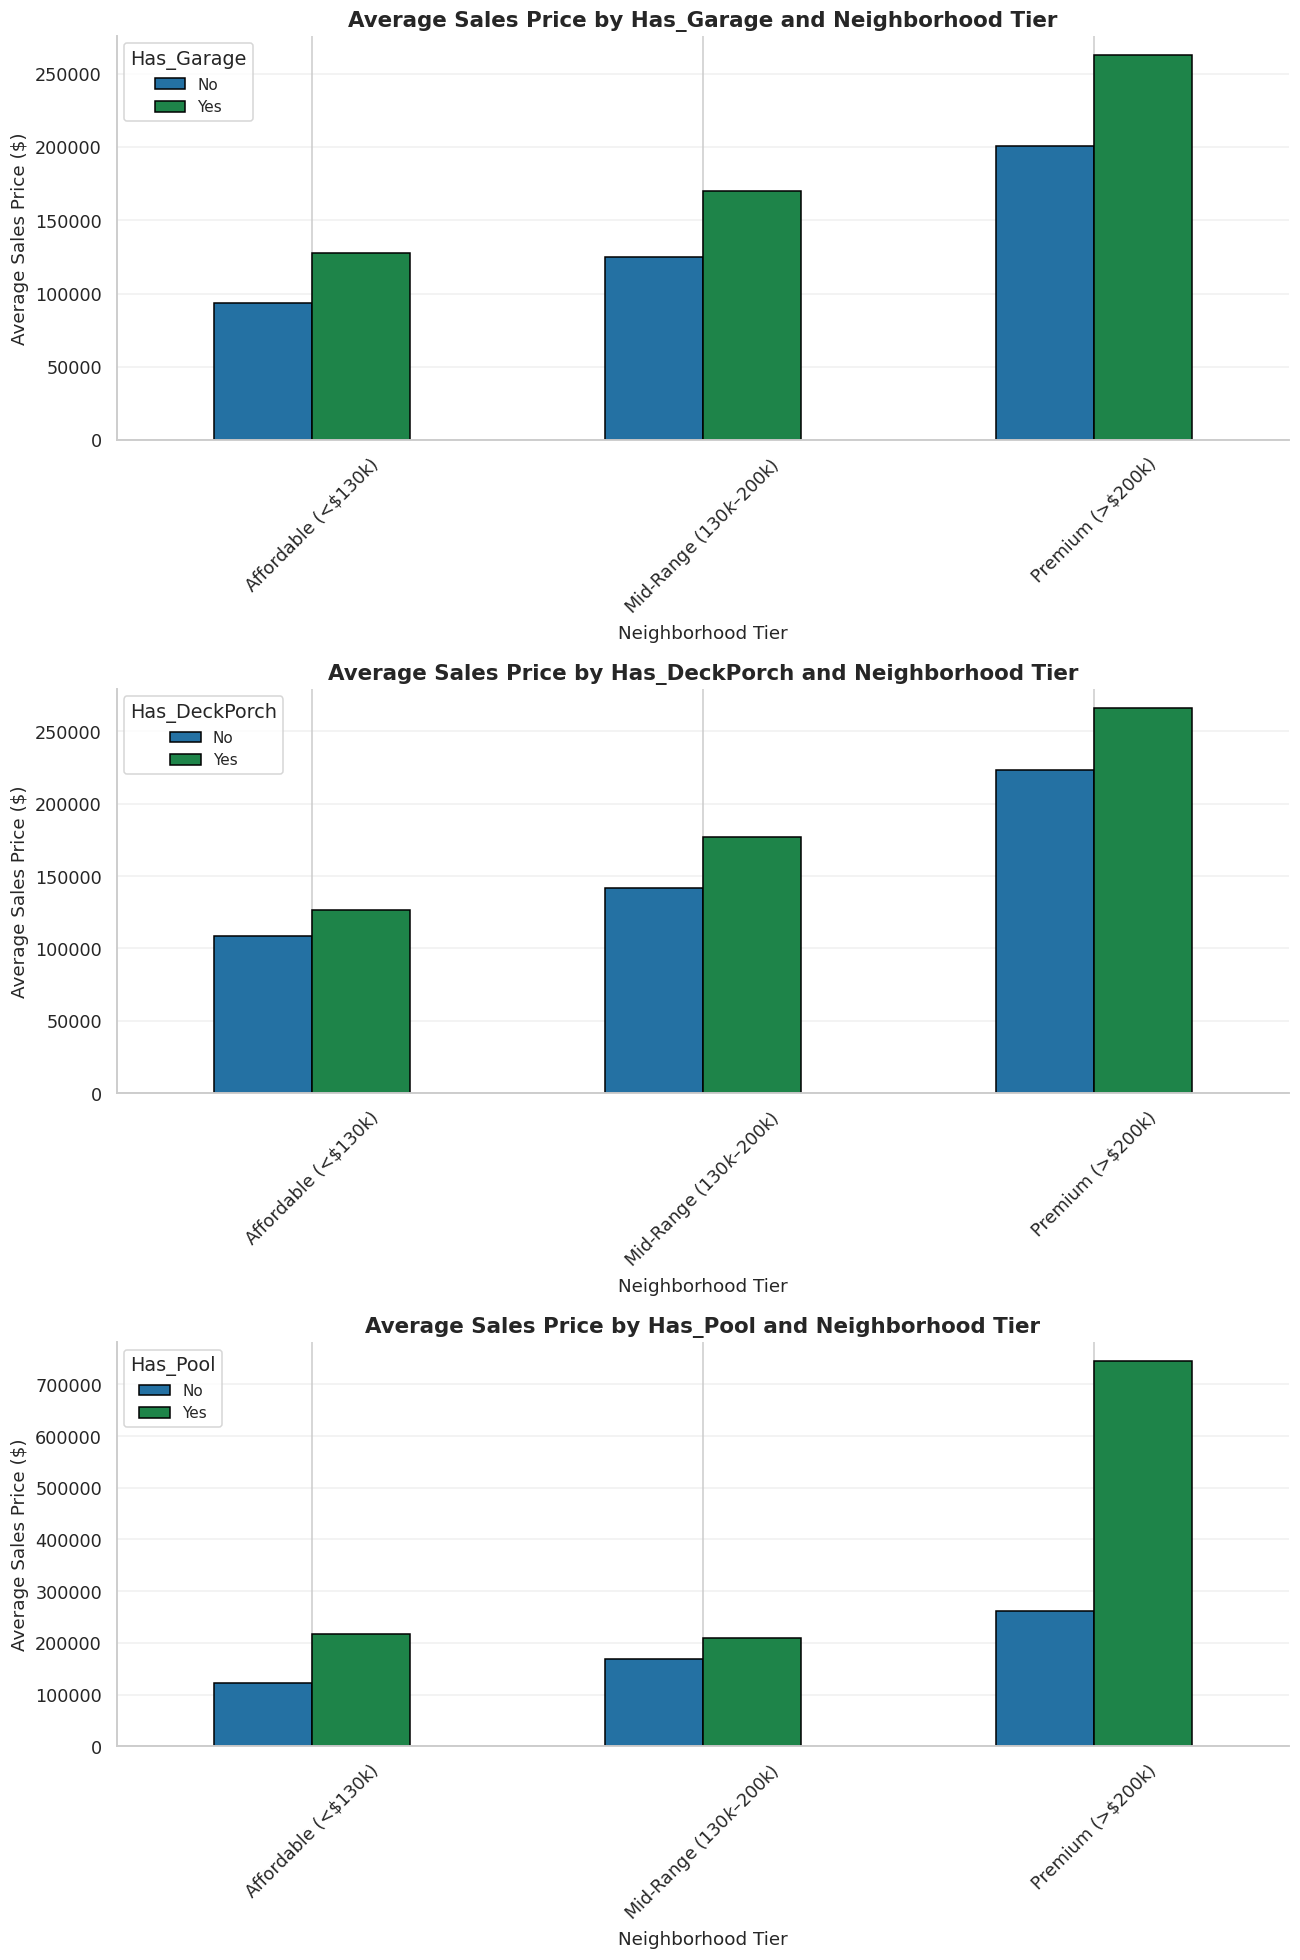


SUMMARY: AMENITY IMPACT ON SALES PRICE BY NEIGHBORHOOD TIER

--- Has_Garage Premiums by Neighborhood Tier ---
NB_Tier
Affordable (<$130k)        36.8
Mid-Range ($130k–$200k)    36.4
Premium (>$200k)           31.1%

--- Has_DeckPorch Premiums by Neighborhood Tier ---
NB_Tier
Affordable (<$130k)        16.9
Mid-Range ($130k–$200k)    24.8
Premium (>$200k)           19.1%

--- Has_Pool Premiums by Neighborhood Tier ---
NB_Tier
Affordable (<$130k)         79.1
Mid-Range ($130k–$200k)     24.0
Premium (>$200k)           185.1%



In [27]:
amenities_to_analyze = ['Has_Garage', 'Has_DeckPorch', 'Has_Pool']

fig, axes = plt.subplots(len(amenities_to_analyze), 1, figsize=(12, 6 * len(amenities_to_analyze)))

for i, amenity_col in enumerate(amenities_to_analyze):
    # Group by Neighborhood Tier and Amenity presence to get average SalePrice
    grouped_data = df.groupby(['NB_Tier', amenity_col])['SalePrice'].mean().unstack()

    # Plotting
    grouped_data.plot(kind='bar', ax=axes[i], color=[BLUE,GREEN], edgecolor='black')

    axes[i].set_title(f'Average Sales Price by {amenity_col.replace("Has ", "")} and Neighborhood Tier', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Neighborhood Tier', fontsize=12)
    axes[i].set_ylabel('Average Sales Price ($)', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title=amenity_col.replace("Has ", ""), labels=['No', 'Yes'], fontsize=10)
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Summary of Premiums by Tier for each Amenity
print("\n" + "="*70)
print("SUMMARY: AMENITY IMPACT ON SALES PRICE BY NEIGHBORHOOD TIER")
print("="*70)

for amenity_col in amenities_to_analyze:
    print(f"\n--- {amenity_col.replace('Has ', '')} Premiums by Neighborhood Tier ---")
    grouped_data = df.groupby(['NB_Tier', amenity_col])['SalePrice'].mean().unstack()

    # Calculate premium percentage
    if (True in grouped_data.columns) and (False in grouped_data.columns):
        premium_pct = ((grouped_data[True] / grouped_data[False]) - 1) * 100
        print(premium_pct.fillna(0).round(1).to_string() + '%')
    elif True in grouped_data.columns:
        print("No 'False' category for comparison in some tiers.")
        print(grouped_data[True].to_string())
    elif False in grouped_data.columns:
        print("No 'True' category for comparison in some tiers.")
        print(grouped_data[False].to_string())
    else:
        print("No data for this amenity.")

print("\n" + "="*70)

# How House Age Affects Sales Price for Renovated vs Unrenovated Houses


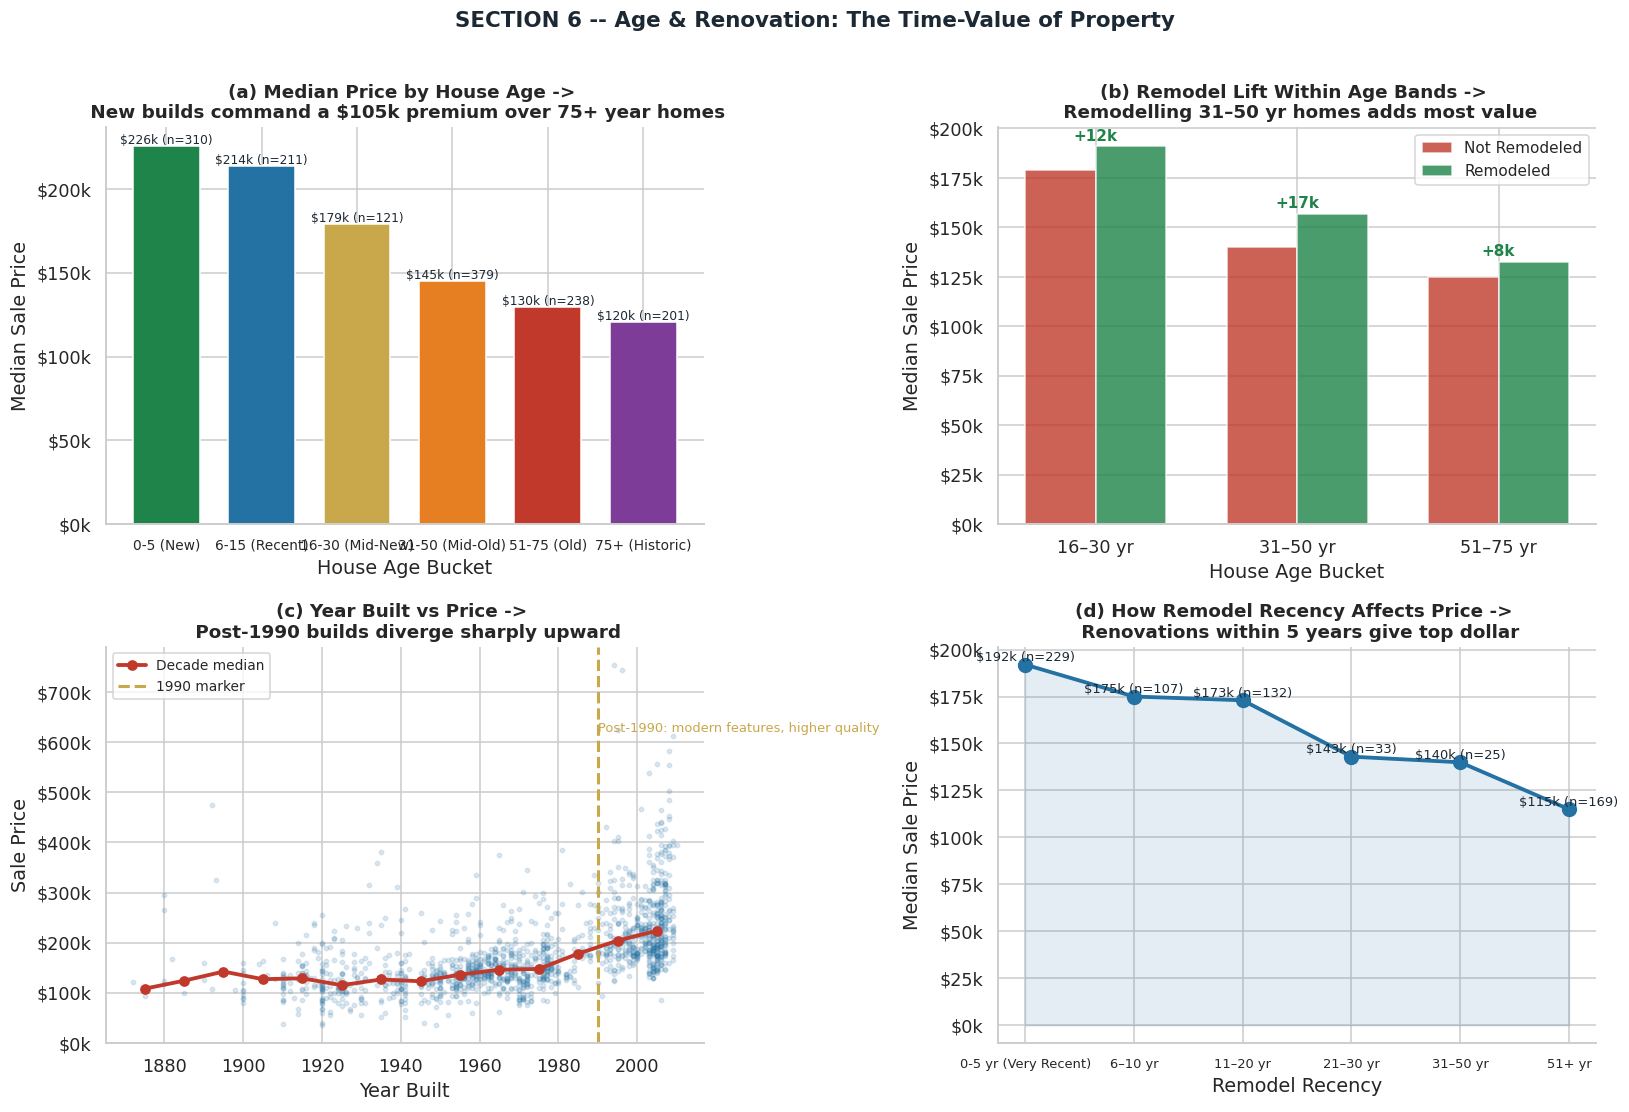


ANALYSIS: HOUSE AGE IMPACT ON SALES PRICE
KEY INSIGHTS FOR SELLERS:
  > New homes (0-5 yr) sell for $105k more than historic (75+ yr) homes.
  > Renovating a 31–50 year old home (the largest age cohort) can add significant value.
  > A renovation within 5 years of sale captures the maximum price premium.
  > Post-1990 builds diverge sharply -- modern layouts and systems are valued by buyers.
  > If your house is 75+ years old, structural limitations cap the remodel ROI.


In [28]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# (a) House age vs price
df['AgeBucket'] = pd.cut(df['HouseAge'],
    bins=[-1, 5, 15, 30, 50, 75, 200],
    labels=['0-5 (New)','6-15 (Recent)','16-30 (Mid-New)','31-50 (Mid-Old)','51-75 (Old)','75+ (Historic)'])
age_stats = df.groupby('AgeBucket', observed=True)['SalePrice'].agg(['median','count'])
age_colors = [GREEN, BLUE, GOLD, ORANGE, RED, PURPLE]
bars = axes[0,0].bar(range(len(age_stats)), age_stats['median']/1000,
                      color=age_colors, edgecolor='white', width=0.7)
axes[0,0].set_xticks(range(len(age_stats)))
axes[0,0].set_xticklabels(age_stats.index, fontsize=9)
axes[0,0].set_xlabel('House Age Bucket')
axes[0,0].set_ylabel('Median Sale Price')
axes[0,0].yaxis.set_major_formatter(mtick.FuncFormatter(fmt_k))
axes[0,0].set_title('(a) Median Price by House Age -> \n New builds command a $105k premium over 75+ year homes')
for bar, (idx, row) in zip(bars, age_stats.iterrows()):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, row['median']/1000 + 1.5,
                   f"${row['median']/1000:.0f}k (n={row['count']:.0f})",
                   ha='center', fontsize=8, color=DARK)

# (b) Remodel effect within age groups
mid_age = df[df.HouseAge.between(15, 75)].copy()
mid_age['AgeBand'] = pd.cut(mid_age['HouseAge'],
    bins=[14,30,50,75], labels=['16–30 yr','31–50 yr','51–75 yr'])
rm_stats = mid_age.groupby(['AgeBand','WasRemodeled'], observed=True)['SalePrice'].median().unstack() / 1000
x = np.arange(len(rm_stats))
w = 0.35
bars_no  = axes[0,1].bar(x - w/2, rm_stats.get(0, pd.Series([0]*len(x))), w,
                           color=RED, alpha=0.8, label='Not Remodeled', edgecolor='white')
bars_yes = axes[0,1].bar(x + w/2, rm_stats.get(1, pd.Series([0]*len(x))), w,
                           color=GREEN, alpha=0.8, label='Remodeled', edgecolor='white')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(rm_stats.index)
axes[0,1].set_xlabel('House Age Bucket')
axes[0,1].set_ylabel('Median Sale Price')
axes[0,1].yaxis.set_major_formatter(mtick.FuncFormatter(fmt_k))
axes[0,1].set_title('(b) Remodel Lift Within Age Bands -> \n Remodelling 31–50 yr homes adds most value')
axes[0,1].legend(fontsize=10)
if 0 in rm_stats.columns and 1 in rm_stats.columns:
    for i, (no_val, yes_val) in enumerate(zip(rm_stats[0], rm_stats[1])):
        diff = yes_val - no_val
        color = GREEN if diff > 0 else RED
        axes[0,1].text(i, max(no_val, yes_val) + 3, f'{diff:+.0f}k',
                       ha='center', fontsize=10, color=color, fontweight='bold')

# (c) Year built vs price scatter with decadal trend
from scipy.stats import binned_statistic
bin_edges  = np.arange(1870, 2015, 10)
medians, edges, _ = binned_statistic(df['YearBuilt'], df['SalePrice']/1000, 'median', bins=bin_edges)
centers = (edges[:-1] + edges[1:]) / 2
valid = ~np.isnan(medians)

axes[1,0].scatter(df['YearBuilt'], df['SalePrice']/1000, alpha=0.15, s=8, color=BLUE)
axes[1,0].plot(centers[valid], medians[valid], 'o-', color=RED, lw=2.5, ms=6, zorder=5,
               label='Decade median')
axes[1,0].axvline(1990, ls='--', color=GOLD, lw=2, label='1990 marker')
axes[1,0].yaxis.set_major_formatter(mtick.FuncFormatter(fmt_k))
axes[1,0].set_xlabel('Year Built')
axes[1,0].set_ylabel('Sale Price')
axes[1,0].set_title('(c) Year Built vs Price -> \n Post-1990 builds diverge sharply upward')
axes[1,0].legend(fontsize=9)
axes[1,0].text(1990, 620, 'Post-1990: modern features, higher quality', fontsize=8.5, color=GOLD)
# (d) Remodel recency
remodeled = df[df.WasRemodeled == 1].copy()
remodeled['RemodelRecency'] = pd.cut(remodeled['RemodelAge'],
    bins=[-1,5,10,20,30,50,100],
    labels=['0-5 yr (Very Recent)','6–10 yr','11–20 yr','21–30 yr','31–50 yr','51+ yr'])
rem_stats = remodeled.groupby('RemodelRecency', observed=True)['SalePrice'].agg(['median','count'])

axes[1,1].plot(range(len(rem_stats)), rem_stats['median']/1000, 'o-',
               color=BLUE, lw=2.5, ms=9)
axes[1,1].fill_between(range(len(rem_stats)), rem_stats['median']/1000,
                        alpha=0.12, color=BLUE)
axes[1,1].set_xticks(range(len(rem_stats)))
axes[1,1].set_xticklabels(rem_stats.index, fontsize=8.5)
axes[1,1].set_xlabel('Remodel Recency')
axes[1,1].set_ylabel('Median Sale Price')
axes[1,1].yaxis.set_major_formatter(mtick.FuncFormatter(fmt_k))
axes[1,1].set_title('(d) How Remodel Recency Affects Price -> \n Renovations within 5 years give top dollar')
for i, (idx, row) in enumerate(rem_stats.iterrows()):
    axes[1,1].text(i, row['median']/1000 + 2, f"${row['median']/1000:.0f}k (n={row['count']:.0f})",
                   ha='center', fontsize=8.5, color=DARK)

plt.suptitle('SECTION 6 -- Age & Renovation: The Time-Value of Property',
             fontsize=14, y=1.01, color=DARK, fontweight='bold')
plt.tight_layout()
plt.show()
# Summary Statistics
print("\n" + "="*70)
print("ANALYSIS: HOUSE AGE IMPACT ON SALES PRICE")
print("="*70)

print("KEY INSIGHTS FOR SELLERS:")
print("  > New homes (0-5 yr) sell for $105k more than historic (75+ yr) homes.")
print("  > Renovating a 31–50 year old home (the largest age cohort) can add significant value.")
print("  > A renovation within 5 years of sale captures the maximum price premium.")
print("  > Post-1990 builds diverge sharply -- modern layouts and systems are valued by buyers.")
print("  > If your house is 75+ years old, structural limitations cap the remodel ROI.")


# **Shruti**

## Location: How Much Is Neighbourhood Worth?


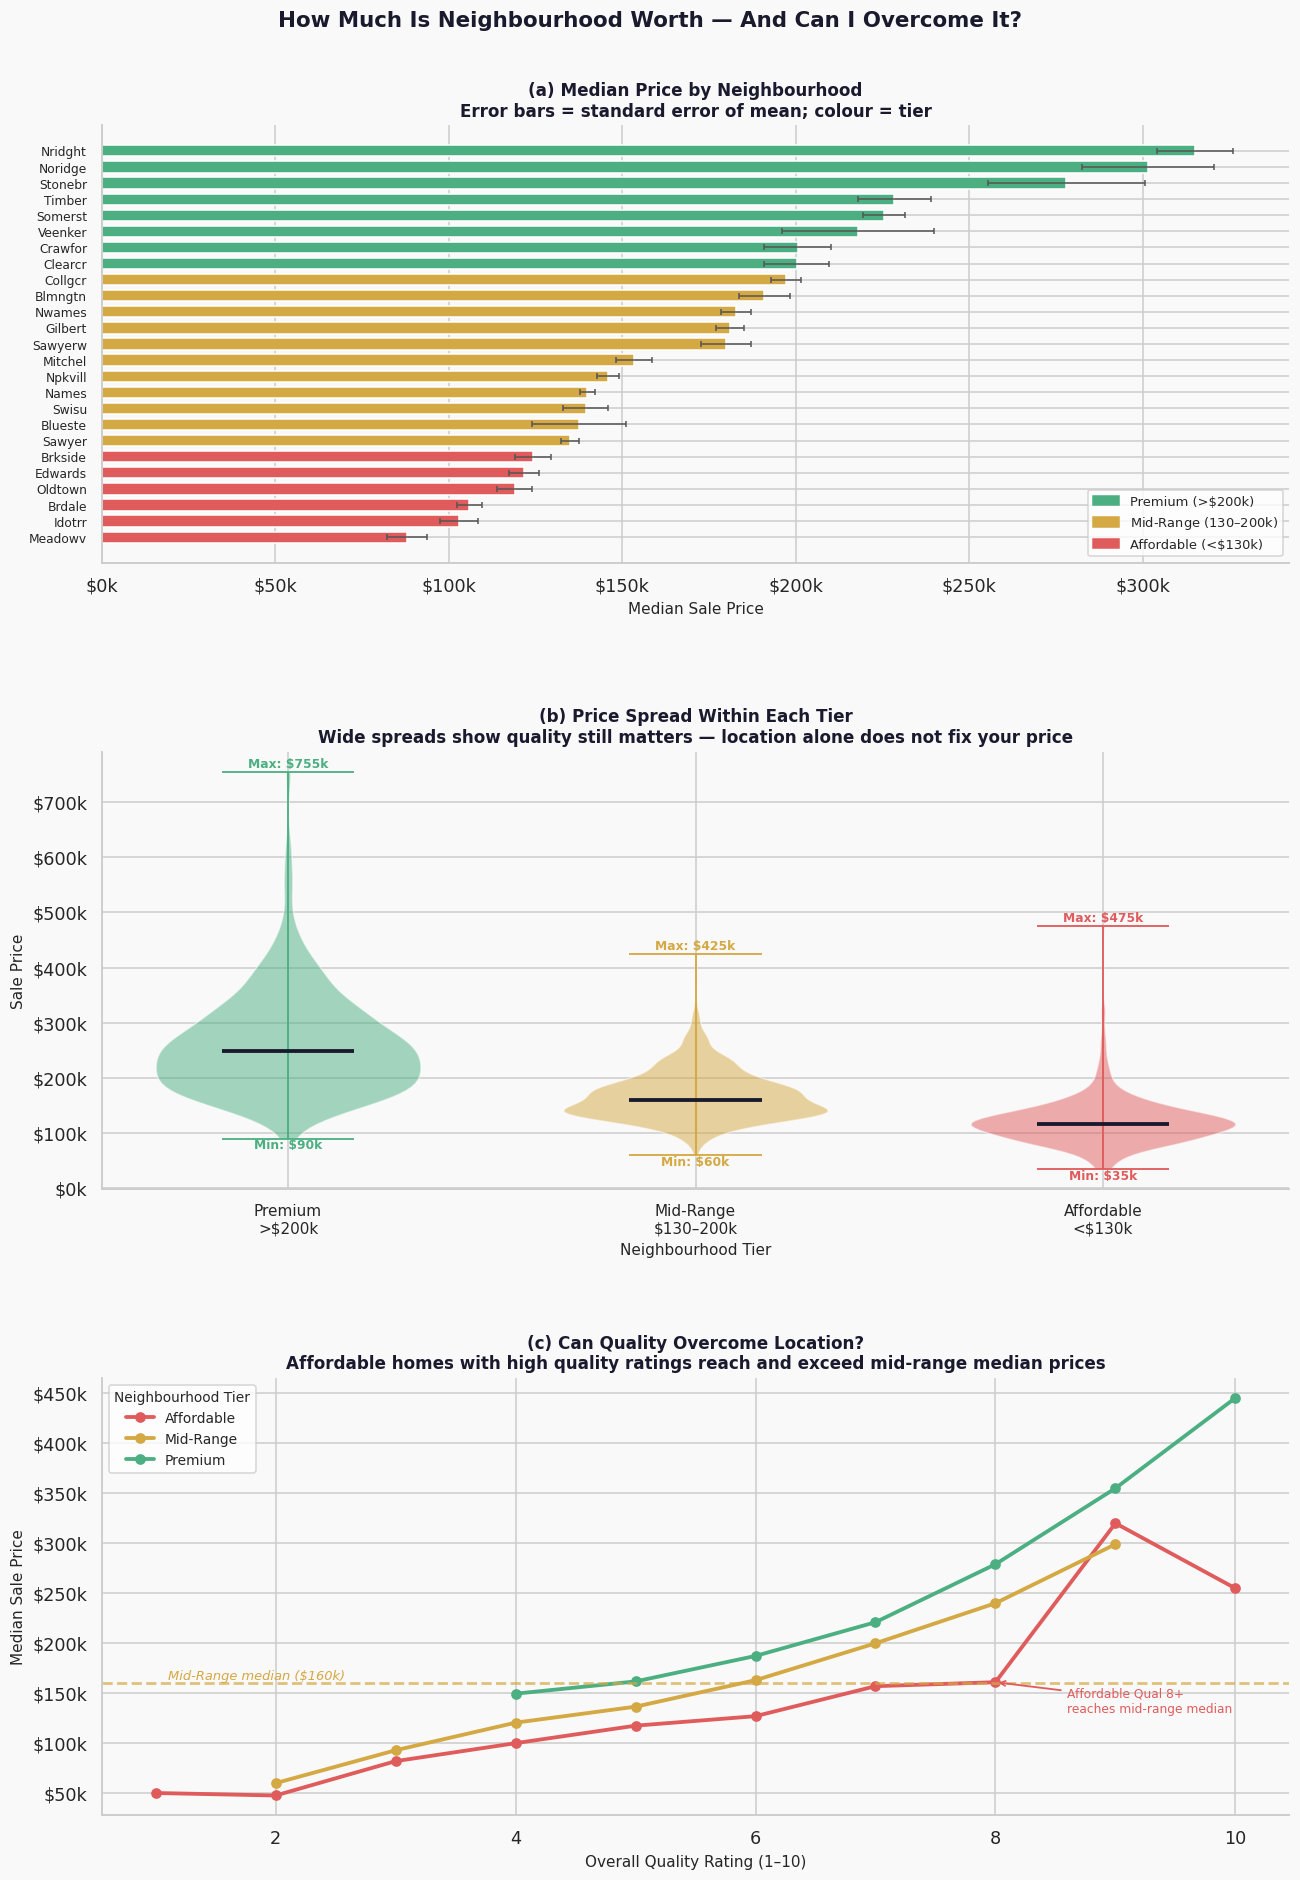

In [29]:
DARK  = '#1a1a2e'
RED   = '#e05c5c'
GOLD  = '#d4a843'
GREEN = '#4caf82'
fmt_k = lambda x, _: f'${x:.0f}k'

fig, axes = plt.subplots(3, 1, figsize=(12, 17))
fig.patch.set_facecolor('#f9f9f9')

#(a) Neighbourhood rank by median price
nb_stats = df.groupby('Neighborhood')['SalePrice'].agg(['median','count','std']).sort_values('median')
tier_color_map = {nb: (RED if nb_median[nb] < 130_000 else (GOLD if nb_median[nb] < 200_000 else GREEN))
                  for nb in nb_stats.index}
bar_colors_nb = [tier_color_map[nb] for nb in nb_stats.index]

axes[0].barh(range(len(nb_stats)), nb_stats['median']/1000,
             xerr=nb_stats['std']/1000/np.sqrt(nb_stats['count']),
             color=bar_colors_nb, height=0.7, edgecolor='white',
             error_kw=dict(elinewidth=1, capsize=2, ecolor='#555'))
axes[0].set_yticks(range(len(nb_stats)))
axes[0].set_yticklabels(nb_stats.index, fontsize=8)
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(fmt_k))
axes[0].set_xlabel('Median Sale Price', fontsize=10)
axes[0].set_title('(a) Median Price by Neighbourhood\nError bars = standard error of mean; colour = tier',
                  fontsize=11, fontweight='bold', color=DARK)
legend_els = [Patch(color=GREEN, label='Premium (>$200k)'),
              Patch(color=GOLD,  label='Mid-Range ($130–$200k)'),
              Patch(color=RED,   label='Affordable (<$130k)')]
axes[0].legend(handles=legend_els, fontsize=8.5, loc='lower right')
axes[0].set_facecolor('#f9f9f9')
axes[0].spines[['top','right']].set_visible(False)

#(b) Price spread within tiers (violinplot)
tier_order  = ['Premium (>$200k)', 'Mid-Range ($130k–$200k)', 'Affordable (<$130k)']
tier_colors = [GREEN, GOLD, RED]
tier_labels = ['Premium\n>$200k', 'Mid-Range\n$130–200k', 'Affordable\n<$130k']

for i, (tier, color) in enumerate(zip(tier_order, tier_colors)):
    data = df[df.NB_Tier == tier]['SalePrice'] / 1000
    vp = axes[1].violinplot(data.values, positions=[i], showmedians=True, widths=0.65)
    for pc in vp['bodies']:
        pc.set_facecolor(color); pc.set_alpha(0.5)
    vp['cmedians'].set_color(DARK); vp['cmedians'].set_linewidth(2.5)
    for key in ['cbars','cmaxes','cmins']:
        vp[key].set_color(color); vp[key].set_linewidth(1.2)
    axes[1].text(i, data.max() + 8,  f'Max: ${data.max():.0f}k', ha='center', fontsize=8, color=color, fontweight='bold')
    axes[1].text(i, data.min() - 18, f'Min: ${data.min():.0f}k', ha='center', fontsize=8, color=color, fontweight='bold')

axes[1].set_xticks(range(len(tier_order)))
axes[1].set_xticklabels(tier_labels, fontsize=10)
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(fmt_k))
axes[1].set_ylabel('Sale Price', fontsize=10)
axes[1].set_xlabel('Neighbourhood Tier', fontsize=10)
axes[1].set_title('(b) Price Spread Within Each Tier\nWide spreads show quality still matters — location alone does not fix your price',
                  fontsize=11, fontweight='bold', color=DARK)
axes[1].set_facecolor('#f9f9f9')
axes[1].spines[['top','right']].set_visible(False)

#  (c) Quality vs price by tier
affrd    = df[df.NB_Tier == 'Affordable (<$130k)']
midrange = df[df.NB_Tier == 'Mid-Range ($130k–$200k)']
prem     = df[df.NB_Tier == 'Premium (>$200k)']

for data, label, color in [(affrd,'Affordable',RED),(midrange,'Mid-Range',GOLD),(prem,'Premium',GREEN)]:
    qual_med = data.groupby('OverallQual')['SalePrice'].median() / 1000
    axes[2].plot(qual_med.index, qual_med.values, 'o-', color=color, lw=2.5, ms=6, label=label)

mid_med_k = midrange['SalePrice'].median() / 1000
axes[2].axhline(mid_med_k, ls='--', color=GOLD, lw=1.8, alpha=0.7)
axes[2].text(1.1, mid_med_k + 4, f'Mid-Range median (${mid_med_k:.0f}k)', fontsize=8.5, color=GOLD, fontstyle='italic')

affrd_q = affrd.groupby('OverallQual')['SalePrice'].median() / 1000
cross = affrd_q[affrd_q >= mid_med_k]
if not cross.empty:
    cross_q = cross.index[0]
    axes[2].annotate(f'Affordable Qual {cross_q}+\nreaches mid-range median',
                     xy=(cross_q, affrd_q[cross_q]),
                     xytext=(cross_q + 0.6, affrd_q[cross_q] - 30),
                     fontsize=8, color=RED,
                     arrowprops=dict(arrowstyle='->', color=RED, lw=1.2))

axes[2].yaxis.set_major_formatter(mtick.FuncFormatter(fmt_k))
axes[2].set_xlabel('Overall Quality Rating (1–10)', fontsize=10)
axes[2].set_ylabel('Median Sale Price', fontsize=10)
axes[2].set_title('(c) Can Quality Overcome Location?\nAffordable homes with high quality ratings reach and exceed mid-range median prices',
                  fontsize=11, fontweight='bold', color=DARK)
axes[2].legend(fontsize=9, title='Neighbourhood Tier', title_fontsize=9)
axes[2].set_facecolor('#f9f9f9')
axes[2].spines[['top','right']].set_visible(False)

fig.suptitle('How Much Is Neighbourhood Worth — And Can I Overcome It?',
             fontsize=14, y=1.005, color=DARK, fontweight='bold')
plt.tight_layout(h_pad=4)
plt.show()

In [30]:
qual_ladder = df.groupby('OverallQual')['SalePrice'].median().sort_index()
print(qual_ladder)
print("\nStep-by-step increments:")
print(qual_ladder.diff().dropna())

OverallQual
1      50150.0
2      60000.0
3      86250.0
4     108000.0
5     133000.0
6     160000.0
7     200141.0
8     269750.0
9     345000.0
10    432390.0
Name: SalePrice, dtype: float64

Step-by-step increments:
OverallQual
2      9850.0
3     26250.0
4     21750.0
5     25000.0
6     27000.0
7     40141.0
8     69609.0
9     75250.0
10    87390.0
Name: SalePrice, dtype: float64


In [31]:
# Tier medians
tier_medians = df.groupby('NB_Tier')['SalePrice'].median()
print(tier_medians)

print(f"\nPremium median:    ${tier_medians['Premium (>$200k)']:,.0f}")
print(f"Affordable median: ${tier_medians['Affordable (<$130k)']:,.0f}")
print(f"Gap:               ${tier_medians['Premium (>$200k)'] - tier_medians['Affordable (<$130k)']:,.0f}")

NB_Tier
Affordable (<$130k)        117000.0
Mid-Range ($130k–$200k)    160100.0
Premium (>$200k)           248900.0
Name: SalePrice, dtype: float64

Premium median:    $248,900
Affordable median: $117,000
Gap:               $131,900


In [32]:
for label, idx in [('Most Expensive', df['SalePrice'].idxmax()),
                   ('Least Expensive', df['SalePrice'].idxmin())]:
    row = df.loc[idx]
    print(f"{label}:")
    print(f"  Price:        ${row['SalePrice']:,.0f}")
    print(f"  Neighbourhood: {row['Neighborhood']}")
    print(f"  Quality:       {row['OverallQual']}/10")
    print(f"  Living Area:   {row['GrLivArea']:,} sq ft")
    print()

Most Expensive:
  Price:        $755,000
  Neighbourhood: Noridge
  Quality:       10/10
  Living Area:   4,316 sq ft

Least Expensive:
  Price:        $34,900
  Neighbourhood: Idotrr
  Quality:       4/10
  Living Area:   720 sq ft



## Key Insights

<ol>
<li>The median price difference between premium and affordable areas is approximately 227,000.</li>
<li>There is no guarantee that not all homes in premium areas sell at premium prices</li>
<li>Location strongly impacts property value, but location alone does not determine the final selling price.</li>
<li>Affordable areas also contain some surprisingly high-priced properties</li>
<li>Some high-quality homes in affordable neighborhoods achieve prices comparable to those found in mid-range areas</li>
<li>It suggests that the neighbourhoods in which the property is located affects the property price. But, a quality upgrade , for example from  5 to 7 can fetch approximately 67,000 in additional value. Again an upgrade from 6 to 8 yields approximately 109,750.</li>
<li>Sellers in affordable neighbourhoods should focus on improving quality and presentation to outperform the local market average</li>
<li>Location largely establishes the baseline price range, while property quality influences where a home falls within that range</li>
</ol>


##Timing the Sale: When Should You List?


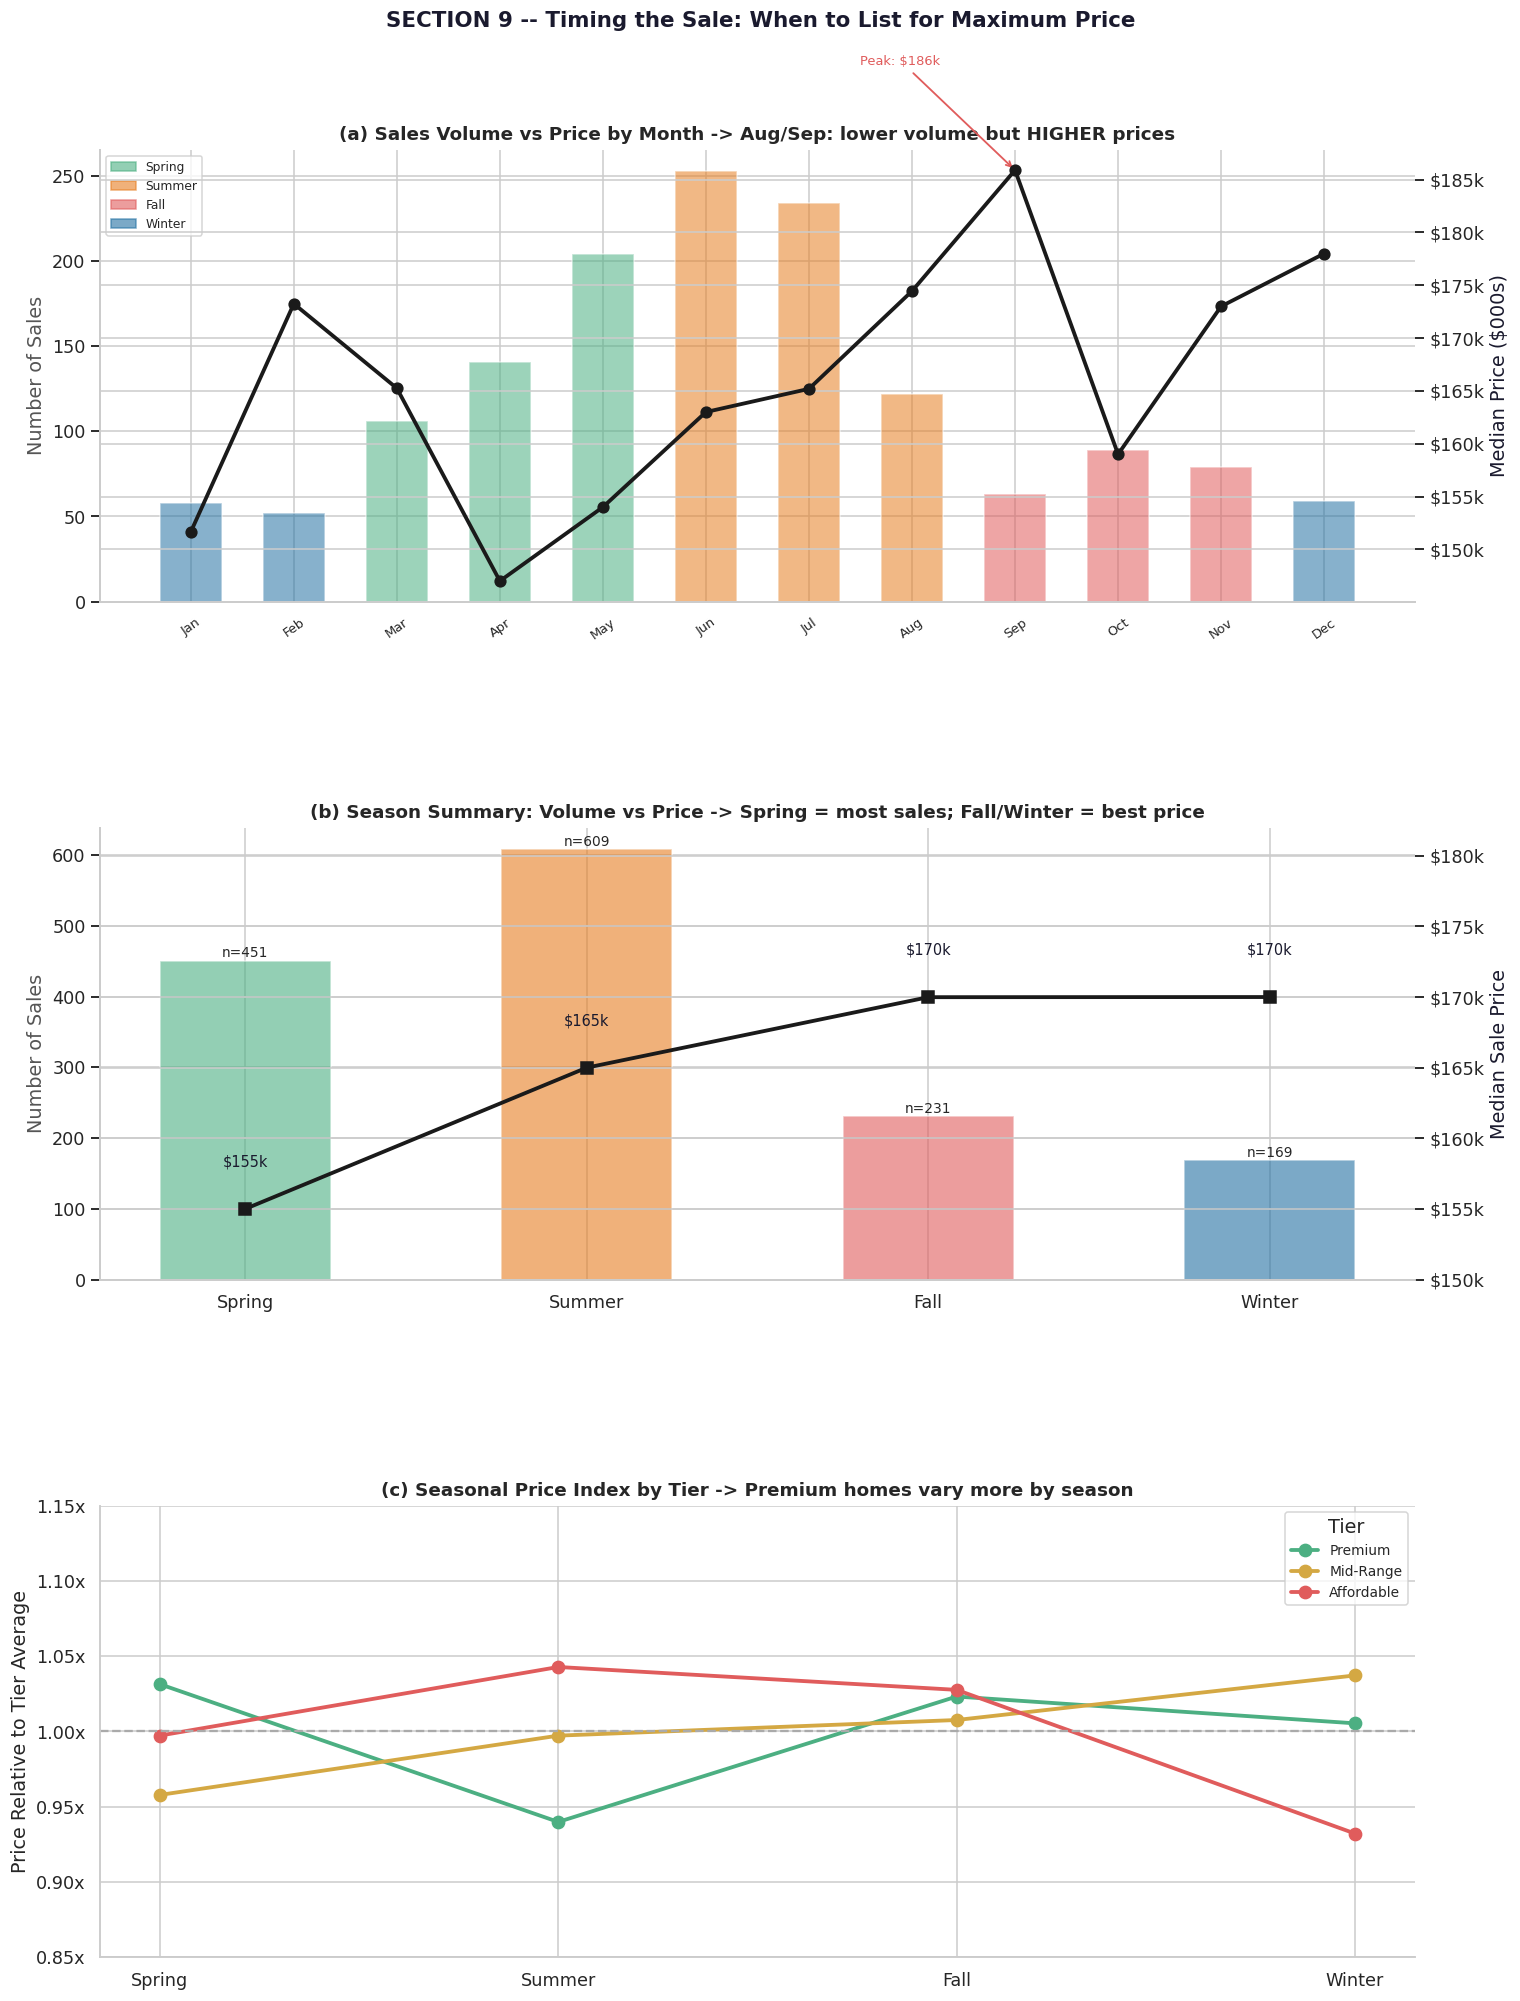

In [33]:
BLUE    = '#2471A3'
ORANGE  = '#E67E22'

fig, axes = plt.subplots(3, 1, figsize=(14, 18))
season_order = ['Spring','Summer','Fall','Winter']
season_colors_map = {'Spring':GREEN,'Summer':ORANGE,'Fall':RED,'Winter':BLUE}

# (a) Volume vs median price by month
mo_stats = df.groupby('MoSold')['SalePrice'].agg(['count','median'])
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax_count = axes[0]
ax_price = ax_count.twinx()
bars = ax_count.bar(range(1,13), mo_stats['count'],
                     color=[season_colors_map[get_season(m)] for m in range(1,13)],
                     alpha=0.55, width=0.6)
ax_price.plot(range(1,13), mo_stats['median']/1000, 'ko-', ms=7, lw=2.5, zorder=5)
ax_count.set_xticks(range(1,13))
ax_count.set_xticklabels(month_names, rotation=35, fontsize=8.5)
ax_count.set_ylabel('Number of Sales', color='#555')
ax_price.set_ylabel('Median Price ($000s)', color=DARK)
ax_price.yaxis.set_major_formatter(mtick.FuncFormatter(fmt_k))
axes[0].set_title('(a) Sales Volume vs Price by Month -> Aug/Sep: lower volume but HIGHER prices')

from matplotlib.patches import Patch
seas_legend = [Patch(color=c, label=s, alpha=0.6) for s, c in season_colors_map.items()]
ax_count.legend(handles=seas_legend, fontsize=8, loc='upper left')

peak_mo = mo_stats['median'].idxmax()
ax_price.annotate(f'Peak: ${mo_stats.loc[peak_mo,"median"]/1000:.0f}k',
                   xy=(peak_mo, mo_stats.loc[peak_mo,'median']/1000),
                   xytext=(peak_mo-1.5, mo_stats.loc[peak_mo,'median']/1000 + 10),
                   fontsize=8.5, color=RED,
                   arrowprops=dict(arrowstyle='->', color=RED, lw=1.2))

# (b) Volume vs price by season
season_stats = df.groupby('Season')['SalePrice'].agg(['count','median','std'])
season_stats = season_stats.reindex(season_order)
ax_s = axes[1]
ax_sp = ax_s.twinx()
b = ax_s.bar(season_order, season_stats['count'],
              color=[season_colors_map[s] for s in season_order], alpha=0.6, width=0.5)
ax_sp.plot(season_order, season_stats['median']/1000, 'ks-', ms=8, lw=2.5, zorder=5)

for i, (s, row) in enumerate(season_stats.iterrows()):
    ax_s.text(i, row['count']+5, f"n={row['count']:.0f}", ha='center', fontsize=9)
    ax_sp.text(i, row['median']/1000 + 3, f"${row['median']/1000:.0f}k", ha='center', fontsize=9.5, color=DARK)

ax_s.set_ylabel('Number of Sales', color='#555')
ax_sp.set_ylabel('Median Sale Price', color=DARK)
ax_sp.yaxis.set_major_formatter(mtick.FuncFormatter(fmt_k))
axes[1].set_title('(b) Season Summary: Volume vs Price -> Spring = most sales; Fall/Winter = best price')

# Give the twin axis some headroom so the $Xk text labels don't collide with subplot (a)
ax_sp.set_ylim(season_stats['median'].min()/1000 - 5, season_stats['median'].max()/1000 + 12)

# (c) Seasonal pricing by neighbourhood tier
tier_season = df.groupby(['NB_Tier','Season'])['SalePrice'].median().unstack()
tier_season = tier_season[season_order]
ts_rel = tier_season.div(tier_season.mean(axis=1), axis=0)
for tier, color in [('Premium (>$200k)',GREEN),('Mid-Range ($130k–$200k)',GOLD),('Affordable (<$130k)',RED)]:
    if tier in ts_rel.index:
        axes[2].plot(season_order, ts_rel.loc[tier].values, 'o-',
                     color=color, lw=2.5, ms=8, label=tier.split('(')[0].strip())
axes[2].axhline(1.0, ls='--', color='#aaa', lw=1.5)
axes[2].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.2f}x'))
axes[2].set_ylabel('Price Relative to Tier Average')
axes[2].set_title('(c) Seasonal Price Index by Tier -> Premium homes vary more by season')
axes[2].legend(fontsize=9, title='Tier')
axes[2].set_ylim(0.85, 1.15)

plt.suptitle('SECTION 9 -- Timing the Sale: When to List for Maximum Price',
             fontsize=14, y=1.01, color=DARK, fontweight='bold')

# Only ONE layout call, applied LAST, so nothing overrides your spacing
plt.tight_layout()
plt.subplots_adjust(hspace=0.5, top=0.94)

plt.show()



1. The median sale price is highest (186k dollars) in September, despite having lower number of sales than the peak season of June.
2. In the winter season of December there is above average (177.5k$) pricing.
3. Spring and summer seasons have most number of sales, but the selling prices are lesser compared to the fall and winter seasons.
4. The prices of property  sold during the fall and winter season are higher.
5. The peak season for selling premium homes is spring, mid-range homes is in winter and affordable homes is in summer.


# **Sanket**

**Correlations**

In [34]:
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
df['PricePerSF'] = df['SalePrice'] / df['GrLivArea']

corr_grliv = df['GrLivArea'].corr(df['SalePrice'])
corr_totalsf = df['TotalSF'].corr(df['SalePrice'])
corr_lotarea = df['LotArea'].corr(df['SalePrice'])

sizebins = pd.cut(df['GrLivArea'], bins=[0,1000,1500,2000,2500,3000,6000],
                   labels=['<1000','1000-1500','1500-2000','2000-2500','2500-3000','3000+'])
df['SizeBin'] = sizebins

big_low_qual = df[(df['GrLivArea'] > 2500) & (df['OverallQual'] <= 5)]
small_high_qual = df[(df['GrLivArea'] < 1500) & (df['OverallQual'] >= 8)]

comp = pd.DataFrame({
    'Avg Price': [big_low_qual['SalePrice'].mean(), small_high_qual['SalePrice'].mean()],
    'Count': [len(big_low_qual), len(small_high_qual)]
}, index=['Big & Low Quality\n(>2500sf, Qual<=5)', 'Small & High Quality\n(<1500sf, Qual>=8)'])

print(f"Correlation - GrLivArea vs SalePrice: {corr_grliv:.3f}")
print(f"Correlation - TotalSF vs SalePrice: {corr_totalsf:.3f}")
print(f"Correlation - LotArea vs SalePrice: {corr_lotarea:.3f}")

Correlation - GrLivArea vs SalePrice: 0.709
Correlation - TotalSF vs SalePrice: 0.782
Correlation - LotArea vs SalePrice: 0.264


**Living Area vs Sale Price**

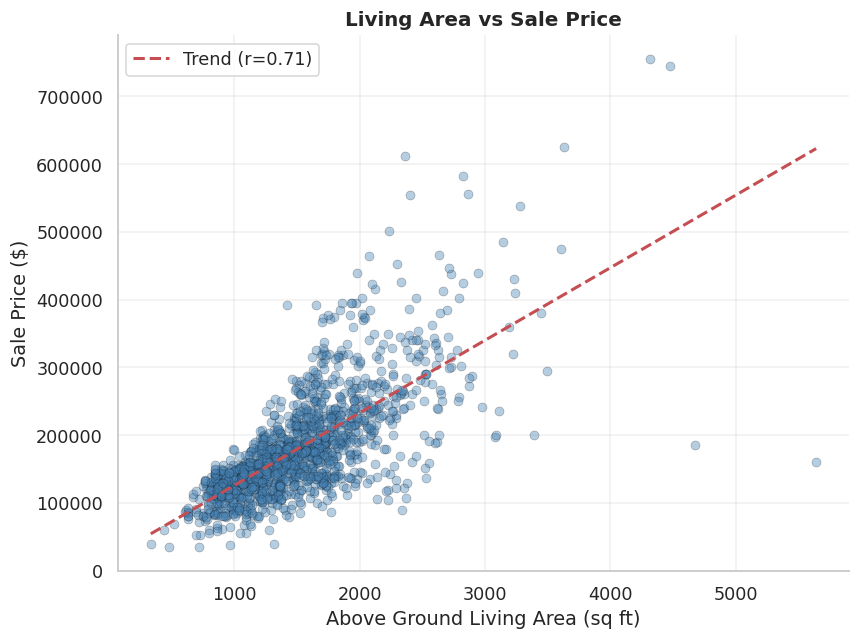

In [35]:
fig1, ax1 = plt.subplots(figsize=(8, 6))
ax1.scatter(df['GrLivArea'], df['SalePrice'], alpha=0.4, s=35,
            color='steelblue', edgecolors='black', linewidth=0.3)
z = np.polyfit(df['GrLivArea'], df['SalePrice'], 1)
p = np.poly1d(z)
xs = np.linspace(df['GrLivArea'].min(), df['GrLivArea'].max(), 100)
ax1.plot(xs, p(xs), 'r--', linewidth=2, label=f'Trend (r={corr_grliv:.2f})')
ax1.set_title('Living Area vs Sale Price', fontsize=13, fontweight='bold')
ax1.set_xlabel('Above Ground Living Area (sq ft)')
ax1.set_ylabel('Sale Price ($)')
ax1.legend()
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Property price for each Sq Ft**

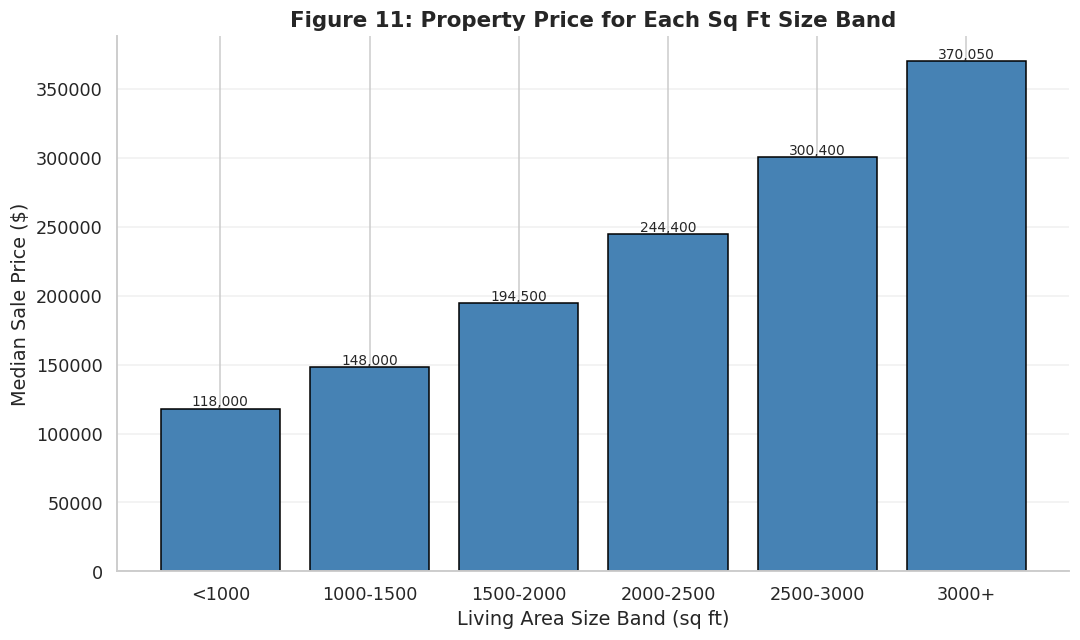

In [36]:
bins = [0, 1000, 1500, 2000, 2500, 3000, 10000]
labels = ['<1000', '1000-1500', '1500-2000', '2000-2500', '2500-3000', '3000+']
df['SizeBand'] = pd.cut(df['GrLivArea'], bins=bins, labels=labels, include_lowest=True, right=False)

size_stats = df.groupby('SizeBand', observed=False)['SalePrice'].agg(['median', 'mean', 'count']).reset_index()
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(size_stats['SizeBand'].astype(str), size_stats['median'], color='steelblue', edgecolor='black')

for i, v in enumerate(size_stats['median']):
    ax.text(i, v + 2000, f"{int(v):,}", ha='center', fontsize=9)

ax.set_title('Figure 11: Property Price for Each Sq Ft Size Band', fontsize=14, fontweight='bold')
ax.set_xlabel('Living Area Size Band (sq ft)')
ax.set_ylabel('Median Sale Price ($)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Property Price compared with Sq Ft of basement area**

Correlation: 0.614


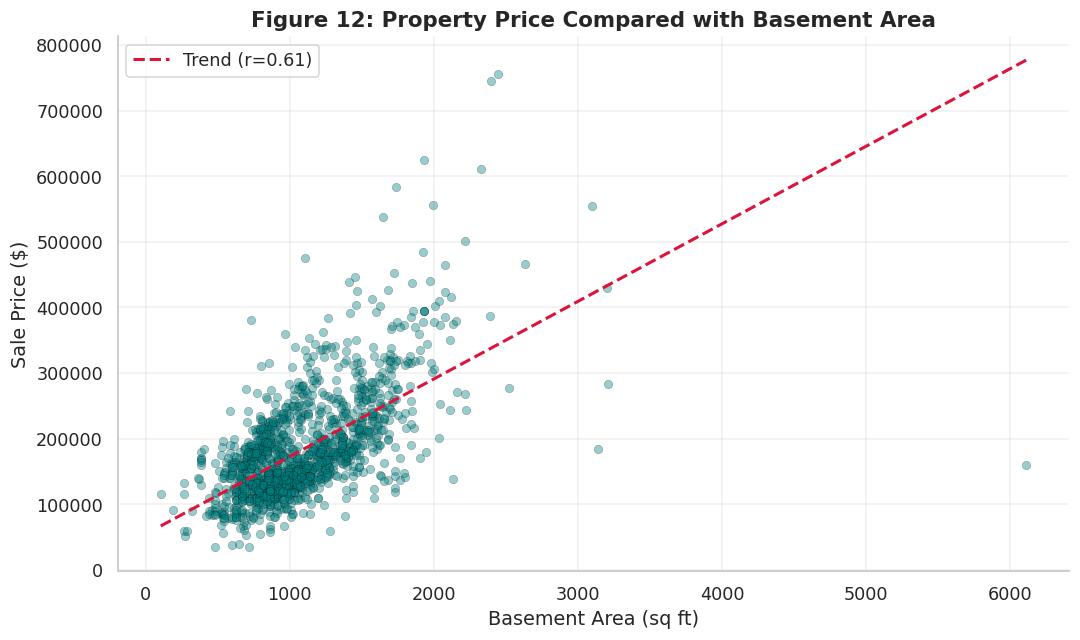

In [37]:
has_bsmt = df[df['TotalBsmtSF'] > 0].copy()
corr_bsmt = df['TotalBsmtSF'].corr(df['SalePrice'])
bsmt_presence = df.assign(BasementPresent=df['TotalBsmtSF'] > 0).groupby('BasementPresent')['SalePrice'].agg(['median', 'mean', 'count']).reset_index()

print('Correlation:', round(corr_bsmt, 3))
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    has_bsmt['TotalBsmtSF'],
    has_bsmt['SalePrice'],
    alpha=0.4,
    s=30,
    color='teal',
    edgecolors='black',
    linewidth=0.3
)

z = np.polyfit(has_bsmt['TotalBsmtSF'], has_bsmt['SalePrice'], 1)
p = np.poly1d(z)
xs = np.linspace(has_bsmt['TotalBsmtSF'].min(), has_bsmt['TotalBsmtSF'].max(), 100)
ax.plot(xs, p(xs), color='crimson', linewidth=2, linestyle='--', label=f'Trend (r={corr_bsmt:.2f})')

ax.set_title('Figure 12: Property Price Compared with Basement Area', fontsize=14, fontweight='bold')
ax.set_xlabel('Basement Area (sq ft)')
ax.set_ylabel('Sale Price ($)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Price per Sq Ft by Size Group**

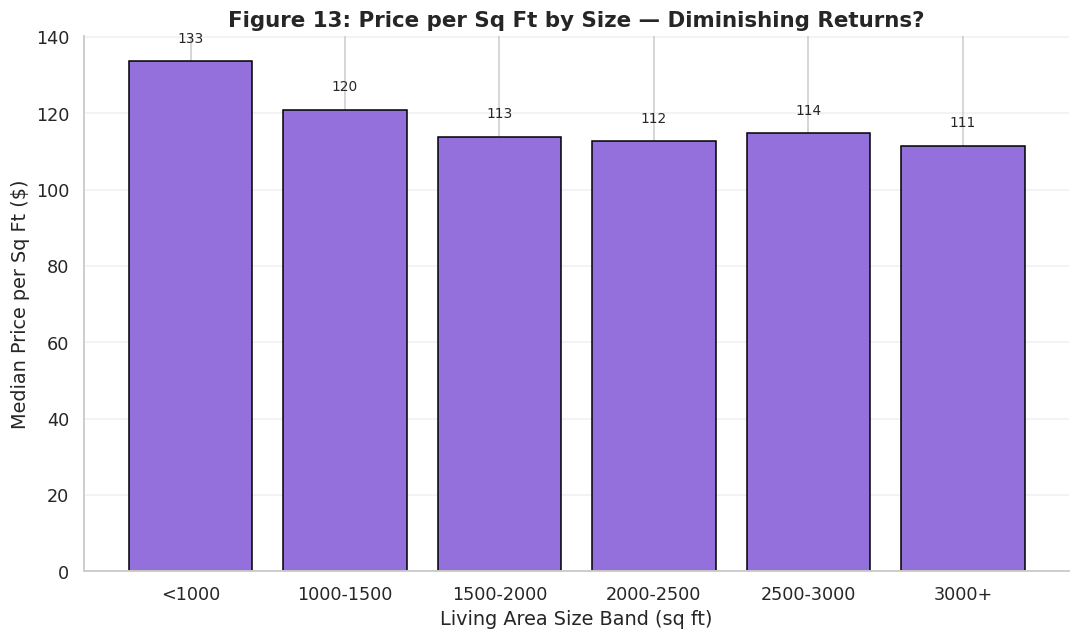

In [38]:
bins = [0, 1000, 1500, 2000, 2500, 3000, 10000]
labels = ['<1000', '1000-1500', '1500-2000', '2000-2500', '2500-3000', '3000+']
df['SizeBand'] = pd.cut(df['GrLivArea'], bins=bins, labels=labels, include_lowest=True, right=False)
ppsf_stats = df.groupby('SizeBand', observed=False)['PricePerSF'].agg(['median', 'mean', 'count']).reset_index()
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(ppsf_stats['SizeBand'].astype(str), ppsf_stats['median'], color='mediumpurple', edgecolor='black')

for i, v in enumerate(ppsf_stats['median']):
    ax.text(i, v + 5, f"{int(v):,}", ha='center', fontsize=9)

ax.set_title('Figure 13: Price per Sq Ft by Size — Diminishing Returns?', fontsize=14, fontweight='bold')
ax.set_xlabel('Living Area Size Band (sq ft)')
ax.set_ylabel('Median Price per Sq Ft ($)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Price with respect to Bedroom count**

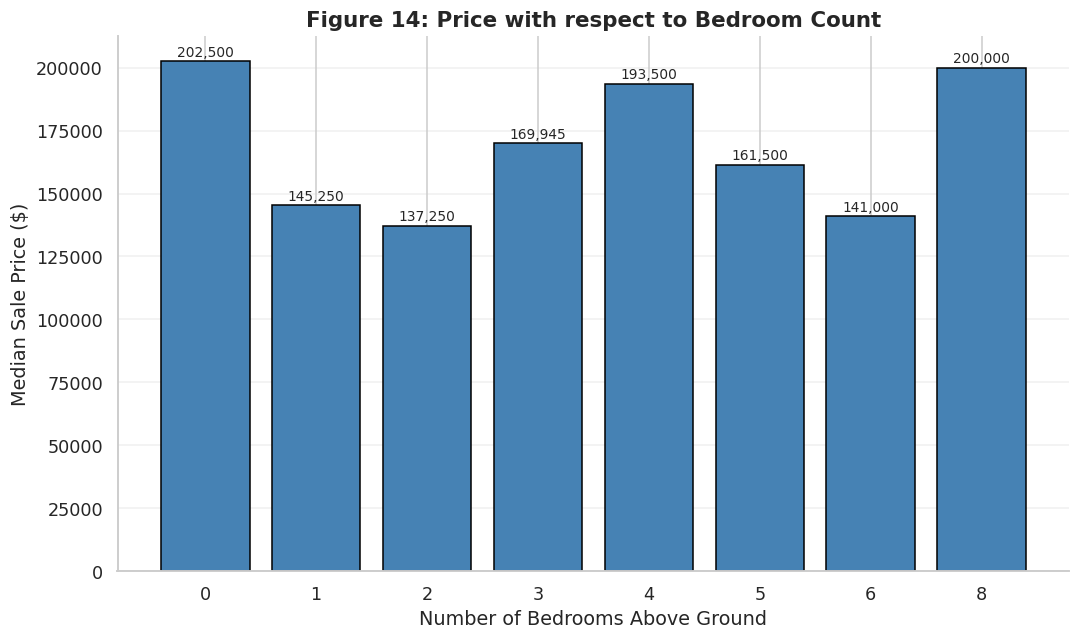

In [39]:
bed_stats = df.groupby('BedroomAbvGr')['SalePrice'].median().reset_index()
bed_stats = bed_stats[bed_stats['BedroomAbvGr'] <= 8]

plt.figure(figsize=(10, 6))
plt.bar(
    bed_stats['BedroomAbvGr'].astype(str),
    bed_stats['SalePrice'],
    color='steelblue',
    edgecolor='black'
)
for i, v in enumerate(bed_stats['SalePrice']):
    plt.text(i, v + 2000, f"{int(v):,}", ha='center', fontsize=9)

plt.title('Figure 14: Price with respect to Bedroom Count', fontsize=14, fontweight='bold')
plt.xlabel('Number of Bedrooms Above Ground')
plt.ylabel('Median Sale Price ($)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Price with respect to Bathroom Count**

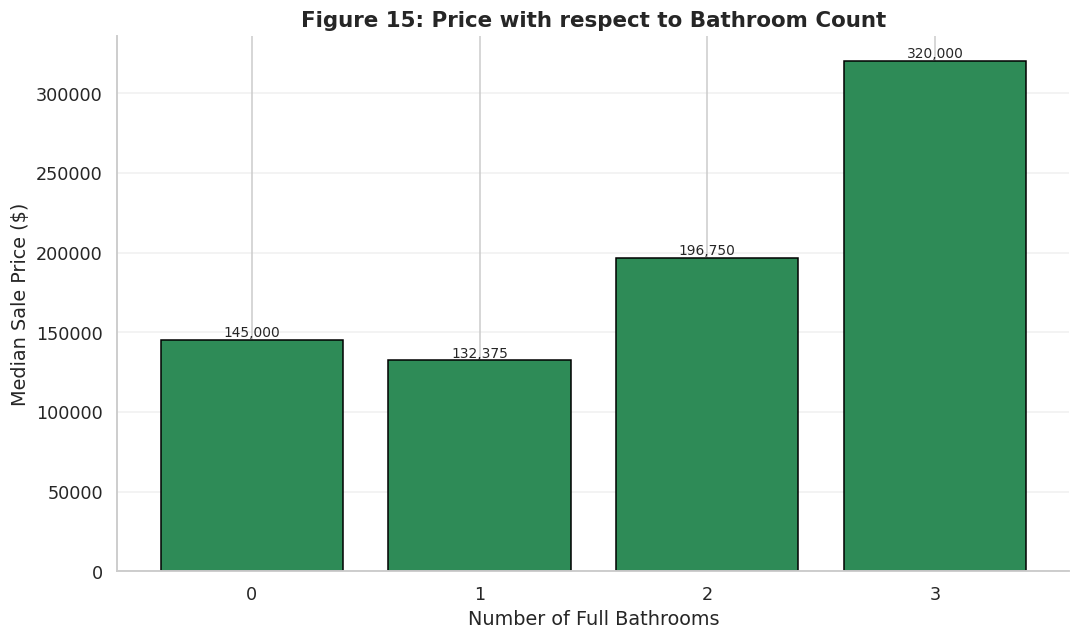

In [40]:
bath_stats = df.groupby('FullBath')['SalePrice'].agg(['median','mean','count']).reset_index().sort_values('FullBath')
bath_stats = bath_stats[bath_stats['FullBath'] <= 4]

plt.figure(figsize=(10, 6))
plt.bar(bath_stats['FullBath'].astype(str), bath_stats['median'], color='seagreen', edgecolor='black')
for i, v in enumerate(bath_stats['median']):
    plt.text(i, v + 2000, f"{int(v):,}", ha='center', fontsize=9)

plt.title('Figure 15: Price with respect to Bathroom Count', fontsize=14, fontweight='bold')
plt.xlabel('Number of Full Bathrooms')
plt.ylabel('Median Sale Price ($)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Which room upgrades move the needle?**

**Price with respect to Count of Fireplaces**

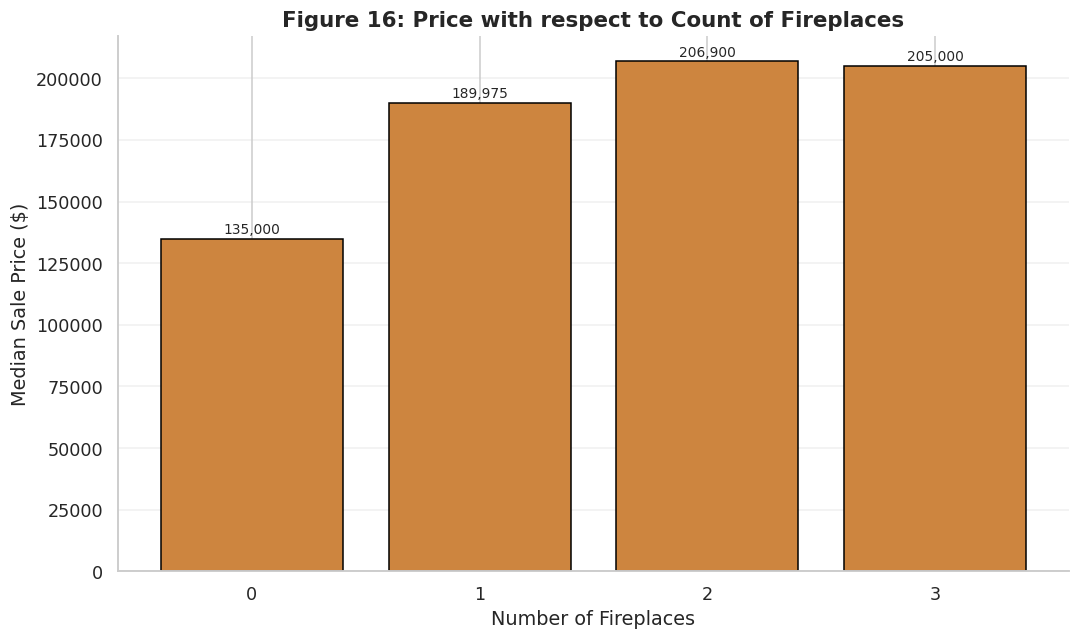

In [41]:
fire_stats = df.groupby('Fireplaces')['SalePrice'].agg(['median', 'mean', 'count']).reset_index()
fire_stats = fire_stats.sort_values('Fireplaces')
fire_stats = fire_stats[fire_stats['Fireplaces'] <= 3]
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(fire_stats['Fireplaces'].astype(str), fire_stats['median'], color='peru', edgecolor='black')

for i, v in enumerate(fire_stats['median']):
    ax.text(i, v + 2000, f"{int(v):,}", ha='center', fontsize=9)

ax.set_title('Figure 16: Price with respect to Count of Fireplaces', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Fireplaces')
ax.set_ylabel('Median Sale Price ($)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Central Air Conditioning**

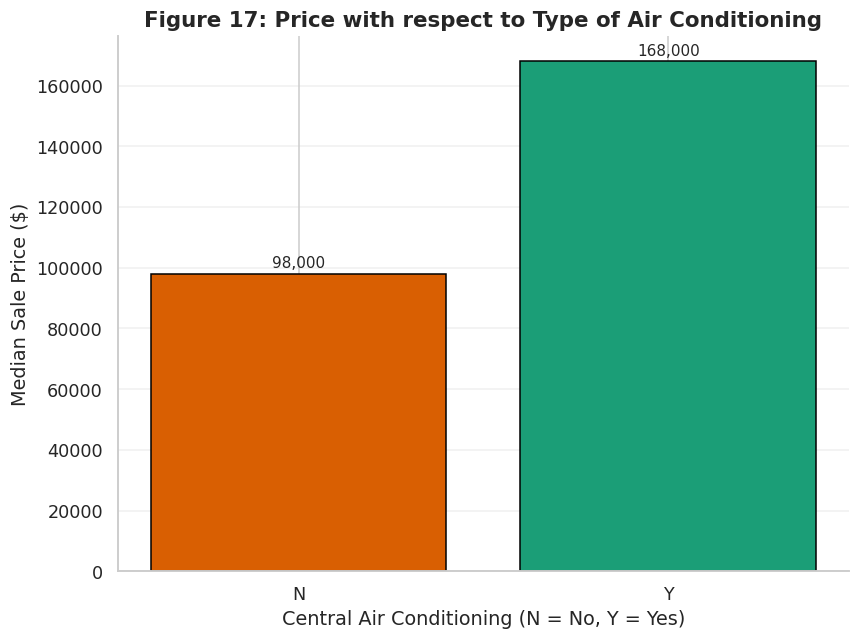

In [42]:
air_stats = df.groupby('CentralAir')['SalePrice'].agg(['median', 'mean', 'count']).reset_index()
air_stats = air_stats.sort_values('CentralAir')
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(air_stats['CentralAir'].astype(str), air_stats['median'], color=['#d95f02', '#1b9e77'], edgecolor='black')

for i, v in enumerate(air_stats['median']):
    ax.text(i, v + 2000, f"{int(v):,}", ha='center', fontsize=10)

ax.set_title('Figure 17: Price with respect to Type of Air Conditioning', fontsize=14, fontweight='bold')
ax.set_xlabel('Central Air Conditioning (N = No, Y = Yes)')
ax.set_ylabel('Median Sale Price ($)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Basement Quality vs Sale Price**

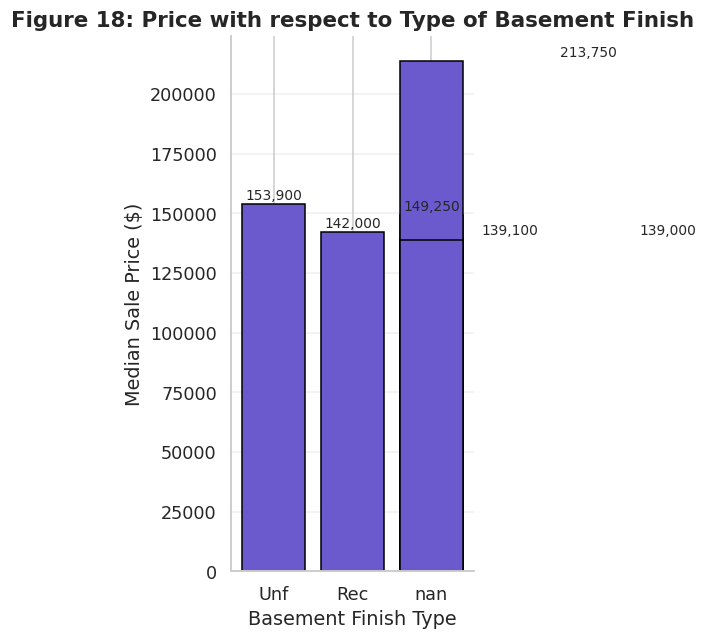

In [43]:
order = ['Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ']
bsmtfin_stats = df.groupby('BsmtFinType1')['SalePrice'].agg(['median', 'mean', 'count']).reset_index()
bsmtfin_stats = bsmtfin_stats[bsmtfin_stats['BsmtFinType1'].notna()]
bsmtfin_stats['BsmtFinType1'] = pd.Categorical(bsmtfin_stats['BsmtFinType1'], categories=order, ordered=True)
bsmtfin_stats = bsmtfin_stats.sort_values('BsmtFinType1')
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(bsmtfin_stats['BsmtFinType1'].astype(str), bsmtfin_stats['median'], color='slateblue', edgecolor='black')

for i, v in enumerate(bsmtfin_stats['median']):
    ax.text(i, v + 2000, f"{int(v):,}", ha='center', fontsize=9)

ax.set_title('Figure 18: Price with respect to Type of Basement Finish', fontsize=14, fontweight='bold')
ax.set_xlabel('Basement Finish Type')
ax.set_ylabel('Median Sale Price ($)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

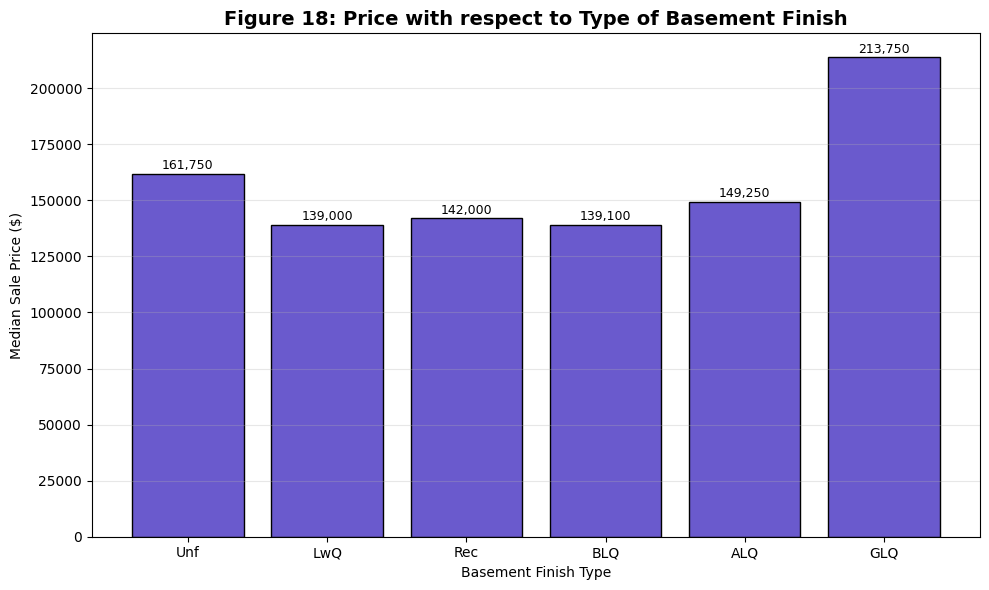

# **KEY INSIGHTS**
1. Larger living areas generally command higher prices (r=0.71), though price variability increases with size and some large homes are sold below the trend line.
2. Total square footage is a stronger predictor of price (r=0.78) than living area alone, though outliers suggest quality or location effects still matter.
3. Larger homes (2,500+ sq ft) don't actually sell for more per square foot , so the idea that bigger always means a higher rate isn't true.
4. Quality can override size like small, high-quality homes (221,019 dollars avg) outsold large, low-quality homes (194,875 dollars avg) by over $26,000.
5. Home quality can beat size, so a smaller well-built house may cost more than a bigger low-quality one.
6. More bathrooms and fireplaces generally increase value.

#Seller's Action Summary

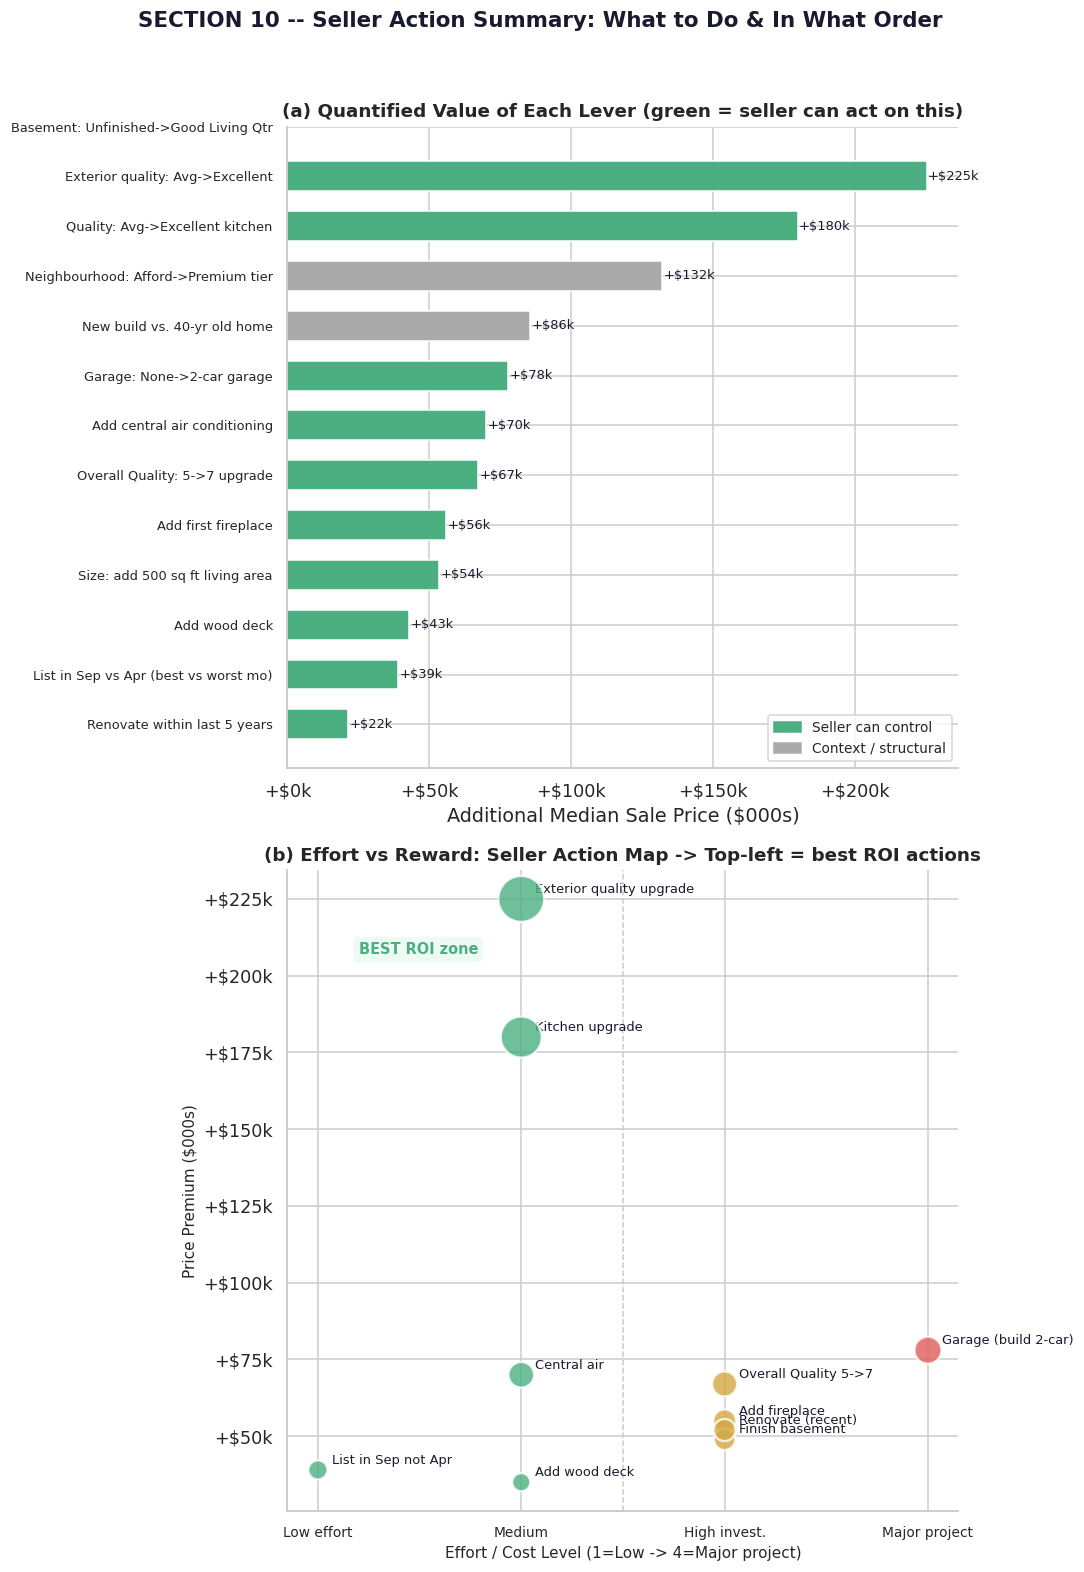

In [44]:
fig, axes = plt.subplots(2, 1, figsize=(10, 14))

# (a) Quantified impact of each lever
levers = {
    'Quality: Avg->Excellent kitchen':       (df[df.KitchenQual=='Excellent']['SalePrice'].median() -
                                             df[df.KitchenQual=='Average']['SalePrice'].median())/1000,
    'Neighbourhood: Afford->Premium tier':    (df[df.NB_Tier=='Premium (>$200k)']['SalePrice'].median() -
                                             df[df.NB_Tier=='Affordable (<$130k)']['SalePrice'].median())/1000,
    'Exterior quality: Avg->Excellent':       (df[df.ExterQual=='Excellent']['SalePrice'].median() -
                                             df[df.ExterQual=='Average']['SalePrice'].median())/1000,
    'Size: add 500 sq ft living area':       0.5 * 107,
    'Garage: None->2-car garage':             (df[df.GarageCars==2]['SalePrice'].median() -
                                             df[df.GarageCars==0]['SalePrice'].median())/1000,
    'Overall Quality: 5->7 upgrade':          (df[df.OverallQual==7]['SalePrice'].median() -
                                             df[df.OverallQual==5]['SalePrice'].median())/1000,
    'Add central air conditioning':          (df[df.CentralAir=='Y']['SalePrice'].median() -
                                             df[df.CentralAir=='N']['SalePrice'].median())/1000,
    'Basement: Unfinished->Good Living Qtr': (df[df.BsmtFinType1=='GLQ']['SalePrice'].median() -
                                             df[df.BsmtFinType1=='Unf']['SalePrice'].median())/1000,
    'Add first fireplace':                   (df[df.Fireplaces>=1]['SalePrice'].median() -
                                             df[df.Fireplaces==0]['SalePrice'].median())/1000,
    'New build vs. 40-yr old home':          (df[df.HouseAge<=5]['SalePrice'].median() -
                                             df[df.HouseAge.between(35,45)]['SalePrice'].median())/1000,
    'Renovate within last 5 years':          (df[df.WasRemodeled==1][df.RemodelAge<=5]['SalePrice'].median() -
                                             df[df.WasRemodeled==0]['SalePrice'].median())/1000,
    'Add wood deck':                         (df[df.WoodDeckSF>0]['SalePrice'].median() -
                                             df[df.WoodDeckSF==0]['SalePrice'].median())/1000,
    'List in Sep vs Apr (best vs worst mo)': (df[df.MoSold==9]['SalePrice'].median() -
                                             df[df.MoSold==4]['SalePrice'].median())/1000,
}

lever_series = pd.Series(levers).sort_values()
controllable = ['Add central air conditioning','Add first fireplace','Add wood deck',
                'Overall Quality: 5->7 upgrade','Basement: Unfinished->Good Living Qtr',
                'Add central air conditioning','Exterior quality: Avg->Excellent',
                'Quality: Avg->Excellent kitchen','Renovate within last 5 years',
                'List in Sep vs Apr (best vs worst mo)','Size: add 500 sq ft living area',
                'Garage: None->2-car garage']

bar_colors_lev = [GREEN if l in controllable else '#aaa' for l in lever_series.index]
bars = axes[0].barh(range(len(lever_series)), lever_series.values,
                     color=bar_colors_lev, height=0.6)
axes[0].set_yticks(range(len(lever_series)))
axes[0].set_yticklabels(lever_series.index, fontsize=8.5)
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'+${x:.0f}k'))
axes[0].set_xlabel('Additional Median Sale Price ($000s)')
axes[0].set_title('(a) Quantified Value of Each Lever (green = seller can act on this)')
for bar, val in zip(bars, lever_series.values):
    axes[0].text(val + 0.5, bar.get_y()+bar.get_height()/2,
                 f'+${val:.0f}k', va='center', fontsize=8.5, color=DARK)
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color=GREEN, label='Seller can control'),
                         Patch(color='#aaa',  label='Context / structural')],
               fontsize=9, loc='lower right')

# (b) ROI-style summary -- effort vs reward
effort = {
    'Kitchen upgrade':        (2, 180),
    'Garage (build 2-car)':   (4, 78),
    'Overall Quality 5->7':    (3, 67),
    'Central air':            (2, 70),
    'Add fireplace':          (3, 55),
    'Exterior quality upgrade':(2, 225),
    'Finish basement':        (3, 49),
    'Add wood deck':          (2, 35),
    'Renovate (recent)':      (3, 52),
    'List in Sep not Apr':    (1, 39),
}
labels_e  = list(effort.keys())
efforts_e = [v[0] for v in effort.values()]
rewards_e = [v[1] for v in effort.values()]
effort_labels = {1:'Low effort', 2:'Medium effort', 3:'High effort / investment', 4:'Major project'}
colors_e = [GREEN if e<=2 else (GOLD if e==3 else RED) for e in efforts_e]

sc = axes[1].scatter(efforts_e, rewards_e, s=[r*4 for r in rewards_e],
                      c=colors_e, alpha=0.8, edgecolors='white', linewidth=1.5, zorder=5)
for label, ex, ry in zip(labels_e, efforts_e, rewards_e):
    axes[1].annotate(label, xy=(ex, ry), xytext=(ex+0.07, ry+2),
                     fontsize=8.5, color=DARK)
axes[1].set_xlabel('Effort / Cost Level (1=Low -> 4=Major project)', fontsize=10)
axes[1].set_ylabel('Price Premium ($000s)', fontsize=10)
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'+${x:.0f}k'))
axes[1].set_xticks([1,2,3,4])
axes[1].set_xticklabels(['Low effort','Medium','High invest.','Major project'], fontsize=9)
axes[1].set_title('(b) Effort vs Reward: Seller Action Map -> Top-left = best ROI actions')
axes[1].axvline(2.5, ls='--', color='#ccc', lw=1)
axes[1].text(1.2, max(rewards_e)*0.92, 'BEST ROI zone', fontsize=9.5, color=GREEN,
              fontweight='bold',
              bbox=dict(boxstyle='round,pad=0.4', facecolor='#EAFAF1', alpha=0.8))

plt.suptitle('SECTION 10 -- Seller Action Summary: What to Do & In What Order',
             fontsize=14, y=1.02, color=DARK, fontweight='bold')
plt.tight_layout()
plt.show()

**SELLERS PRIORITISED ACTION LIST**

**QUICK WINS (low effort, meaningful return**
1. List in Aug/Sep - costs nothing, up to +38k
2. Central air (if not present) - +70k, relatively low install"

**HIGH IMPACT INVESTMENTS (medium effort)**

3. Exterior quality upgrade - first impression, +225k gap
4. Kitchen upgrade to Good/Excellent - +64k to 180k
5. Overall quality from 5->7 - +67k"
6. Basement finish (Good Living Quarters) - +49k"

**LONGER-TERM PROJECTS**

7. Add 2-car garage - +78k
8. Renovate recently (within 5 yrs) - +52k
9. Add fireplace - +55k for the first one

**CONTEXT (structural - harder to change)**

10. Neighbourhood tier: premium vs affordable = +227k
11. House age: newer = higher price, but renovation helps


In [45]:
cleaned_df = pd.read_csv("cleaned_dataset.csv")
cleaned_df.head(20)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,HouseAge,WasRemodeled,RemodelAge,TotalSF,PricePerSqFt,Season,NB_Tier,Has_Garage,Has_DeckPorch,Has_Pool
0,1,60,RL,65.0,8450,Pave,Grvl,Reg,Lvl,Allpub,...,5,0,5,2566,121.929825,Winter,Mid-Range ($130k–$200k),True,True,False
1,2,20,RL,80.0,9600,Pave,Grvl,Reg,Lvl,Allpub,...,31,0,31,2524,143.819334,Spring,Premium (>$200k),True,True,False
2,3,60,RL,68.0,11250,Pave,Grvl,IR1,Lvl,Allpub,...,7,1,6,2706,125.139978,Fall,Mid-Range ($130k–$200k),True,True,False
3,4,70,RL,60.0,9550,Pave,Grvl,IR1,Lvl,Allpub,...,91,1,36,2473,81.537566,Winter,Premium (>$200k),True,True,False
4,5,60,RL,84.0,14260,Pave,Grvl,IR1,Lvl,Allpub,...,8,0,8,3343,113.739763,Winter,Premium (>$200k),True,True,False
5,6,50,RL,85.0,14115,Pave,Grvl,IR1,Lvl,Allpub,...,16,1,14,2158,104.992658,Fall,Mid-Range ($130k–$200k),True,True,False
6,7,20,RL,75.0,10084,Pave,Grvl,Reg,Lvl,Allpub,...,3,1,2,3380,181.227863,Summer,Premium (>$200k),True,True,False
7,8,60,RL,69.0,10382,Pave,Grvl,IR1,Lvl,Allpub,...,36,0,36,3197,95.693780,Fall,Mid-Range ($130k–$200k),True,True,False
8,9,50,RM,51.0,6120,Pave,Grvl,Reg,Lvl,Allpub,...,77,1,58,2726,73.224352,Spring,Affordable (<$130k),True,True,False
9,10,190,RL,50.0,7420,Pave,Grvl,Reg,Lvl,Allpub,...,69,1,58,2068,109.563603,Winter,Affordable (<$130k),True,True,False


In [46]:
cleaned_df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [47]:
cleaned_df['NB_Tier'].unique()

array(['Mid-Range ($130k–$200k)', 'Premium (>$200k)',
       'Affordable (<$130k)'], dtype=object)